# Datathon Submission
Nolan Enright & Connor Quadrini

## Notebook Overview & Data-Cleaning Philosophy
- Load raw daily and interval call data for service groups A–D.
- Impute/clean: handle zeros/edge cases, interpolate gaps, drop incomplete days.
- Feature engineering: calendar fields (DoW, month, week, dayofyear), lags/rolling means, Fourier seasonality.
- Model stack: baselines (RF/GB), XGBoost daily + interval expansion, neural nets (torch & sklearn MLP), HistGradientBoosting, and ensemble blends.
- Evaluation: daily MSE/RMSE/R², plots vs actuals.
- Export: interval-level predictions for August, wide combined table for XGB lagged + HGBR.


### Import libraries & setup


In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

A_Daily = pd.read_excel("Data for Datathon (Revised).xlsx" , sheet_name="A - Daily")
A_Interval = pd.read_excel("Data for Datathon (Revised).xlsx" , sheet_name="A - Interval")

B_Daily = pd.read_excel("Data for Datathon (Revised).xlsx" , sheet_name="B - Daily")
B_Interval = pd.read_excel("Data for Datathon (Revised).xlsx" , sheet_name="B - Interval")
C_Daily = pd.read_excel("Data for Datathon (Revised).xlsx" , sheet_name="C - Daily")
C_Interval = pd.read_excel("Data for Datathon (Revised).xlsx" , sheet_name="C - Interval")
D_Daily = pd.read_excel("Data for Datathon (Revised).xlsx" , sheet_name="D - Daily")
D_Interval = pd.read_excel("Data for Datathon (Revised).xlsx" , sheet_name="D - Interval")

Daily_Staffing = pd.read_excel("Data for Datathon (Revised).xlsx" , sheet_name="Daily Staffing")


### Rename columns for clarity


In [2]:
Daily_Staffing = Daily_Staffing.rename(columns={"Unnamed: 0": "Date"})

Daily_Staffing["Date"] = pd.to_datetime(Daily_Staffing["Date"])

Daily_Staffing["Date"] = Daily_Staffing["Date"].dt.strftime("%Y-%B-%-d")

Daily_Staffing = Daily_Staffing.fillna(0)



### Daily Tables


### Interpolate missing daily values


In [3]:
# We can interpolate the Daily tables misisng values

A_Daily["Service Level"] = A_Daily["Service Level"].combine_first(A_Daily["Service Level"].interpolate().bfill().ffill())
A_Daily["CCT"] = A_Daily["CCT"].combine_first(A_Daily["CCT"].interpolate().bfill().ffill())
A_Daily["Call Volume"] = A_Daily["Call Volume"].combine_first(A_Daily["Call Volume"].interpolate().bfill().ffill())
A_Daily["Abandon Rate"] = A_Daily["Abandon Rate"].combine_first(A_Daily["Abandon Rate"].interpolate().bfill().ffill())

B_Daily["Service Level"] = B_Daily["Service Level"].combine_first(B_Daily["Service Level"].interpolate().bfill().ffill())
B_Daily["CCT"] = B_Daily["CCT"].combine_first(B_Daily["CCT"].interpolate().bfill().ffill())
B_Daily["Call Volume"] = B_Daily["Call Volume"].combine_first(B_Daily["Call Volume"].interpolate().bfill().ffill())
B_Daily["Abandon Rate"] = B_Daily["Abandon Rate"].combine_first(B_Daily["Abandon Rate"].interpolate().bfill().ffill())

C_Daily["Service Level"] = C_Daily["Service Level"].combine_first(C_Daily["Service Level"].interpolate().bfill().ffill())
C_Daily["CCT"] = C_Daily["CCT"].combine_first(C_Daily["CCT"].interpolate().bfill().ffill())
C_Daily["Call Volume"] = C_Daily["Call Volume"].combine_first(C_Daily["Call Volume"].interpolate().bfill().ffill())
C_Daily["Abandon Rate"] = C_Daily["Abandon Rate"].combine_first(C_Daily["Abandon Rate"].interpolate().bfill().ffill())

D_Daily["Service Level"] = D_Daily["Service Level"].combine_first(D_Daily["Service Level"].interpolate().bfill().ffill())
D_Daily["CCT"] = D_Daily["CCT"].combine_first(D_Daily["CCT"].interpolate().bfill().ffill())
D_Daily["Call Volume"] = D_Daily["Call Volume"].combine_first(D_Daily["Call Volume"].interpolate().bfill().ffill())
D_Daily["Abandon Rate"] = D_Daily["Abandon Rate"].combine_first(D_Daily["Abandon Rate"].interpolate().bfill().ffill())


Daily_Staffing["A"] = pd.to_numeric(Daily_Staffing["A"], errors="coerce")
Daily_Staffing["A"] = Daily_Staffing["A"].where(
    Daily_Staffing["A"] != 0,
    np.ceil(Daily_Staffing["A"].replace(0, np.nan).interpolate().bfill().ffill())
)

Daily_Staffing["B"] = pd.to_numeric(Daily_Staffing["B"], errors="coerce")
Daily_Staffing["B"] = Daily_Staffing["B"].where(
    Daily_Staffing["B"] != 0,
    np.ceil(Daily_Staffing["B"].replace(0, np.nan).interpolate().bfill().ffill())
)

Daily_Staffing["C"] = pd.to_numeric(Daily_Staffing["C"], errors="coerce")
Daily_Staffing["C"] = Daily_Staffing["C"].where(
    Daily_Staffing["C"] != 0,
    np.ceil(Daily_Staffing["C"].replace(0, np.nan).interpolate().bfill().ffill())
)

Daily_Staffing["D"] = pd.to_numeric(Daily_Staffing["D"], errors="coerce")
Daily_Staffing["D"] = Daily_Staffing["D"].where(
    Daily_Staffing["D"] != 0,
    np.ceil(Daily_Staffing["D"].replace(0, np.nan).interpolate().bfill().ffill())
)





### Interval table cleaning


##### Table A

### Reference: StackOverflow logic


In [4]:
# Source - https://stackoverflow.com/q/66539940
# Posted by hrokr, modified by community. See post 'Timeline' for change history
# Retrieved 2026-03-27, License - CC BY-SA 4.0

# Refactoring Date

A_Interval['Date'] = "2025" + '-' + A_Interval['Month'].map(str) + '-' + A_Interval['Day'].map(str)
pd.to_datetime(A_Interval['Date'], utc=False)

A_Interval = A_Interval.drop('Month', axis=1)
A_Interval = A_Interval.drop('Day', axis=1)

### Edge case: zero call volume


In [5]:
# First special case: When Call volume = 0, we set Service level to 100, Abandonded rate to 0, and CCT to 0

mask = A_Interval["Call Volume"] == 0

A_Interval.loc[mask, "Service Level"] = A_Interval.loc[mask, "Service Level"].fillna(100)
A_Interval.loc[mask, "Abandoned Rate"] = A_Interval.loc[mask, "Abandoned Rate"].fillna(0.0)
A_Interval.loc[mask, "CCT"] = A_Interval.loc[mask, "CCT"].fillna(0)

### Edge case: 100% abandoned


In [6]:
# Second special case: When Abandoned rate = 100%, set service level to 0 and CCT to 0

mask = A_Interval["Abandoned Rate"] == 1

A_Interval.loc[mask, "Service Level"] = A_Interval.loc[mask, "Service Level"].fillna(0)
A_Interval.loc[mask, "CCT"] = A_Interval.loc[mask, "CCT"].fillna(0)

### Edge case: 0% abandoned


In [7]:
# Third special case: When Abandoned rate = 0%, set Abandoned Calls to 0

mask = A_Interval["Abandoned Rate"] == 0

A_Interval.loc[mask, "Abandoned Calls"] = A_Interval.loc[mask, "Service Level"].fillna(0)


### Drop incomplete interval days


In [8]:
# Remove days with missing data from interval table


bad_days_A = A_Interval[A_Interval.isna().any(axis=1)]["Date"].unique()

A_Interval = A_Interval[~A_Interval["Date"].isin(bad_days_A)]

### Verify


In [9]:
# Verify 
A_Interval.isna().sum()

Interval           0
Service Level      0
Call Volume        0
Abandoned Calls    0
Abandoned Rate     0
CCT                0
Date               0
dtype: int64

##### Table B

### Reference: StackOverflow logic


In [10]:
# Source - https://stackoverflow.com/q/66539940
# Posted by hrokr, modified by community. See post 'Timeline' for change history
# Retrieved 2026-03-27, License - CC BY-SA 4.0

# Refactoring Date


B_Interval['Date'] = "2025" + '-' + B_Interval['Month'].map(str) + '-' + B_Interval['Day'].map(str)
pd.to_datetime(B_Interval['Date'], utc=False)

B_Interval = B_Interval.drop('Month', axis=1)
B_Interval = B_Interval.drop('Day', axis=1)

# First special case: When Call volume = 0, we set Service level to 100, Abandonded rate to 0, and CCT to 0

mask = B_Interval["Call Volume"] == 0

B_Interval.loc[mask, "Service Level"] = B_Interval.loc[mask, "Service Level"].fillna(100)
B_Interval.loc[mask, "Abandoned Rate"] = B_Interval.loc[mask, "Abandoned Rate"].fillna(0.0)
B_Interval.loc[mask, "CCT"] = B_Interval.loc[mask, "CCT"].fillna(0)

# Second special case: When Abandoned rate = 100%, set service level to 0 and CCT to 0

mask = B_Interval["Abandoned Rate"] == 1

B_Interval.loc[mask, "Service Level"] = B_Interval.loc[mask, "Service Level"].fillna(0)
B_Interval.loc[mask, "CCT"] = B_Interval.loc[mask, "CCT"].fillna(0)

# Third special case: When Abandoned rate = 0%, set Abandoned Calls to 0

mask = B_Interval["Abandoned Rate"] == 0

A_Interval.loc[mask, "Abandoned Calls"] = B_Interval.loc[mask, "Service Level"].fillna(0)

# Remove days with missing data from interval table


bad_days_B = B_Interval[B_Interval.isna().any(axis=1)]["Date"].unique()

B_Interval = B_Interval[~B_Interval["Date"].isin(bad_days_B)]

# Verify 
B_Interval.isna().sum()

Interval           0
Service Level      0
Call Volume        0
Abandoned Calls    0
Abandoned Rate     0
CCT                0
Date               0
dtype: int64

##### Table C

### Reference: StackOverflow logic


In [11]:
# Source - https://stackoverflow.com/q/66539940
# Posted by hrokr, modified by community. See post 'Timeline' for change history
# Retrieved 2026-03-27, License - CC BY-SA 4.0

# Refactoring Date

C_Interval['Date'] = "2025" + '-' + C_Interval['Month'].map(str) + '-' + C_Interval['Day'].map(str)
pd.to_datetime(C_Interval['Date'], utc=False)

C_Interval = C_Interval.drop('Month', axis=1)
C_Interval = C_Interval.drop('Day', axis=1)

# First special case: When Call volume = 0, we set Service level to 100, Abandonded rate to 0, and CCT to 0

mask = C_Interval["Call Volume"] == 0

C_Interval.loc[mask, "Service Level"] = C_Interval.loc[mask, "Service Level"].fillna(100)
C_Interval.loc[mask, "Abandoned Rate"] = C_Interval.loc[mask, "Abandoned Rate"].fillna(0.0)
C_Interval.loc[mask, "CCT"] = C_Interval.loc[mask, "CCT"].fillna(0)

# Second special case: When Abandoned rate = 100%, set service level to 0 and CCT to 0

mask = C_Interval["Abandoned Rate"] == 1

C_Interval.loc[mask, "Service Level"] = C_Interval.loc[mask, "Service Level"].fillna(0)
C_Interval.loc[mask, "CCT"] = C_Interval.loc[mask, "CCT"].fillna(0)

# Third special case: When Abandoned rate = 0%, set Abandoned Calls to 0

mask = C_Interval["Abandoned Rate"] == 0

A_Interval.loc[mask, "Abandoned Calls"] = C_Interval.loc[mask, "Service Level"].fillna(0)

# Remove days with missing data from interval table


bad_days_C = C_Interval[C_Interval.isna().any(axis=1)]["Date"].unique()

C_Interval = C_Interval[~C_Interval["Date"].isin(bad_days_C)]

# Verify 
C_Interval.isna().sum()

Interval           0
Service Level      0
Call Volume        0
Abandoned Calls    0
Abandoned Rate     0
CCT                0
Date               0
dtype: int64

##### Table D

### Reference: StackOverflow logic


In [12]:
# Source - https://stackoverflow.com/q/66539940
# Posted by hrokr, modified by community. See post 'Timeline' for change history
# Retrieved 2026-03-27, License - CC BY-SA 4.0

# Refactoring Date

D_Interval['Date'] = "2025" + '-' + D_Interval['Month'].map(str) + '-' + D_Interval['Day'].map(str)
pd.to_datetime(D_Interval['Date'], utc=False)

D_Interval = D_Interval.drop('Month', axis=1)
D_Interval = D_Interval.drop('Day', axis=1)

# First special case: When Call volume = 0, we set Service level to 100, Abandonded rate to 0, and CCT to 0

mask = D_Interval["Call Volume"] == 0

D_Interval.loc[mask, "Service Level"] = D_Interval.loc[mask, "Service Level"].fillna(100)
D_Interval.loc[mask, "Abandoned Rate"] = D_Interval.loc[mask, "Abandoned Rate"].fillna(0.0)
D_Interval.loc[mask, "CCT"] = D_Interval.loc[mask, "CCT"].fillna(0)

# Second special case: When Abandoned rate = 100%, set service level to 0 and CCT to 0

mask = D_Interval["Abandoned Rate"] == 1

D_Interval.loc[mask, "Service Level"] = D_Interval.loc[mask, "Service Level"].fillna(0)
D_Interval.loc[mask, "CCT"] = D_Interval.loc[mask, "CCT"].fillna(0)

# Third special case: When Abandoned rate = 0%, set Abandoned Calls to 0

mask = D_Interval["Abandoned Rate"] == 0

A_Interval.loc[mask, "Abandoned Calls"] = D_Interval.loc[mask, "Service Level"].fillna(0)

# Remove days with missing data from interval table


bad_days_D = D_Interval[D_Interval.isna().any(axis=1)]["Date"].unique()

D_Interval = D_Interval[~D_Interval["Date"].isin(bad_days_D)]

# Verify 
D_Interval.isna().sum()

Interval           0
Service Level      0
Call Volume        0
Abandoned Calls    0
Abandoned Rate     0
CCT                0
Date               0
dtype: int64

### Clean Up Dates


### Prepare date fields


In [13]:
# Prep dates
A_Daily["Date"] = pd.to_datetime(A_Daily["Date"])
A_Interval["Date"] = pd.to_datetime(A_Interval["Date"])
B_Daily["Date"] = pd.to_datetime(B_Daily["Date"])
B_Interval["Date"] = pd.to_datetime(B_Interval["Date"])
C_Daily["Date"] = pd.to_datetime(C_Daily["Date"])
C_Interval["Date"] = pd.to_datetime(C_Interval["Date"])
D_Daily["Date"] = pd.to_datetime(D_Daily["Date"])
D_Interval["Date"] = pd.to_datetime(D_Interval["Date"])
Daily_Staffing["Date"] = pd.to_datetime(Daily_Staffing["Date"])

A_Interval = A_Interval.merge(Daily_Staffing[["Date", "A"]], on="Date", how="left")
B_Interval = B_Interval.merge(Daily_Staffing[["Date", "B"]], on="Date", how="left")
C_Interval = C_Interval.merge(Daily_Staffing[["Date", "C"]], on="Date", how="left")
D_Interval = D_Interval.merge(Daily_Staffing[["Date", "D"]], on="Date", how="left")

A_Daily = A_Daily.merge(Daily_Staffing[["Date", "A"]], on="Date", how="left")
B_Daily = B_Daily.merge(Daily_Staffing[["Date", "B"]], on="Date", how="left")
C_Daily = C_Daily.merge(Daily_Staffing[["Date", "C"]], on="Date", how="left")
D_Daily = D_Daily.merge(Daily_Staffing[["Date", "D"]], on="Date", how="left")


A_filled = pd.to_numeric(A_Daily["A"], errors="coerce").ffill().bfill()
A_Daily["A"] = A_Daily["A"].combine_first(A_filled)

B_filled = pd.to_numeric(B_Daily["B"], errors="coerce").ffill().bfill()
B_Daily["B"] = B_Daily["B"].combine_first(B_filled)

C_filled = pd.to_numeric(C_Daily["C"], errors="coerce").ffill().bfill()
C_Daily["C"] = C_Daily["C"].combine_first(C_filled)

D_filled = pd.to_numeric(D_Daily["D"], errors="coerce").ffill().bfill()
D_Daily["D"] = D_Daily["D"].combine_first(D_filled)

A_Daily["Call Volume"] = np.ceil(
    A_Daily["Call Volume"]
).astype(int)
B_Daily["Call Volume"] = np.ceil(
    B_Daily["Call Volume"]
).astype(int)
B_Daily["Call Volume"] = np.ceil(
    B_Daily["Call Volume"]
).astype(int)
B_Daily["Call Volume"] = np.ceil(
    B_Daily["Call Volume"]
).astype(int)



/var/folders/9w/4bhm6y311mxccw3ds9zfltn80000gn/T/ipykernel_35771/183303523.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  A_Daily["Date"] = pd.to_datetime(A_Daily["Date"])
/var/folders/9w/4bhm6y311mxccw3ds9zfltn80000gn/T/ipykernel_35771/183303523.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  B_Daily["Date"] = pd.to_datetime(B_Daily["Date"])
/var/folders/9w/4bhm6y311mxccw3ds9zfltn80000gn/T/ipykernel_35771/183303523.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  C_Daily["Date"] = pd.to_datetime(C_Daily["Date"])
/var/folders/9w/4bhm6y311mxccw3ds9zfltn80000gn/T/

### Modeling


### Sort daily data chronologically


In [14]:


# Sort daily data
A_Daily = A_Daily.sort_values("Date").reset_index(drop=True)

# Create year-month column
A_Daily["year_month"] = A_Daily["Date"].dt.to_period("M")


# Split daily data
A_Daily_Train = A_Daily[A_Daily["year_month"] < "2025-08"].copy()
A_Daily_Test = A_Daily[A_Daily["year_month"] == "2025-08"].copy()

# Train daily regression
X_train = A_Daily_Train.drop(columns=["Date", "year_month", "Call Volume"])
y_train = A_Daily_Train["Call Volume"]

X_test = A_Daily_Test.drop(columns=["Date", "year_month", "Call Volume"])

model = LinearRegression()
model.fit(X_train, y_train)

# Predict daily values for August
A_Daily_Test["Predicted Daily Call Volume"] = model.predict(X_test)

# Rename actual column for clarity
A_Daily_Test = A_Daily_Test.rename(columns={"Call Volume": "Actual Daily Call Volume"})

# Build historical 30-minute pattern
A_Interval["weekday"] = A_Interval["Date"].dt.dayofweek

pattern = (
    A_Interval.groupby(["weekday", "Interval"])["Call Volume"]
    .mean()
)

pattern = pattern / pattern.groupby(level=0).sum()

# Expand to 30-min level
intervals = sorted(A_Interval["Interval"].unique())

A_30min_pred = A_Daily_Test.loc[
    A_Daily_Test.index.repeat(len(intervals))
].copy()

A_30min_pred["Interval"] = intervals * len(A_Daily_Test)
A_30min_pred["weekday"] = A_30min_pred["Date"].dt.dayofweek

# Map weights
A_30min_pred["weight"] = A_30min_pred.set_index(
    ["weekday", "Interval"]
).index.map(pattern)

A_30min_pred["weight"] = A_30min_pred["weight"].fillna(0)

# Final 30-min prediction
A_30min_pred["Interval Prediction"] = (
    A_30min_pred["Predicted Daily Call Volume"] * A_30min_pred["weight"]
)

# 🔥 FINAL CLEAN OUTPUT
A_30min_pred_1  = A_30min_pred[[
    "Date",
    "Actual Daily Call Volume",
    "Predicted Daily Call Volume",
    "Interval",
    "Interval Prediction",
    "weight"
]]

### Compute model metrics


In [15]:
mse = mean_squared_error(
    A_30min_pred_1["Actual Daily Call Volume"],
    A_30min_pred_1["Predicted Daily Call Volume"]
)

print("MSE:", mse)

MSE: 1396683.8507626634


### Plot results


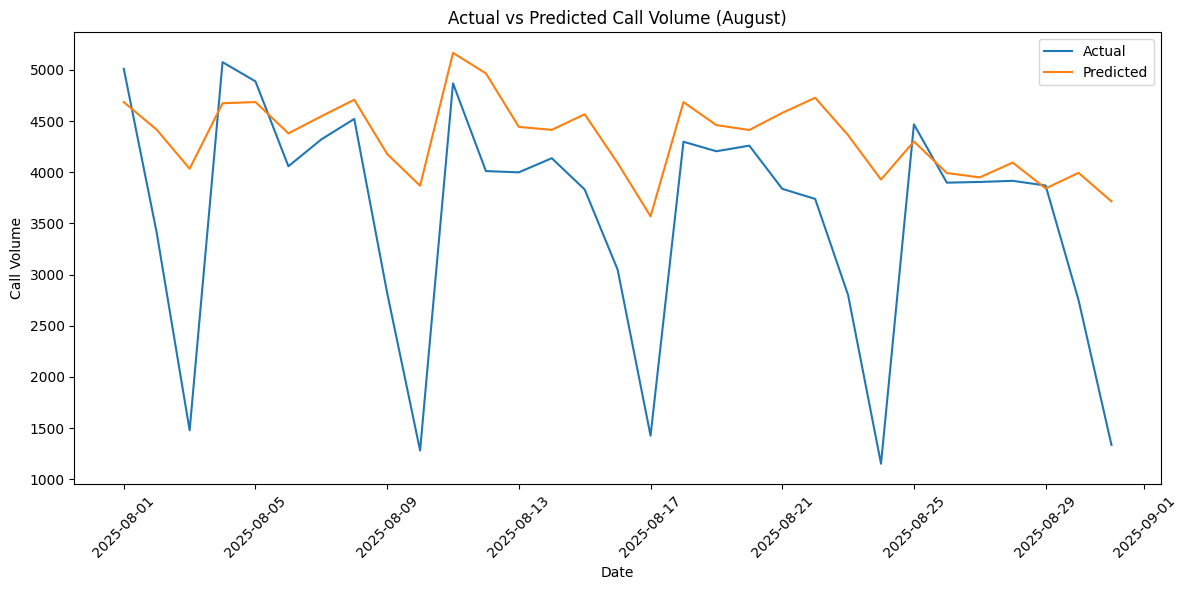

In [16]:
plt.figure(figsize=(12,6))

plt.plot(A_30min_pred_1["Date"], 
         A_30min_pred_1["Actual Daily Call Volume"], 
         label="Actual")

plt.plot(A_30min_pred_1["Date"], 
         A_30min_pred_1["Predicted Daily Call Volume"], 
         label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Call Volume (August)")
plt.xlabel("Date")
plt.ylabel("Call Volume")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The model is underfitting and not capturing weekends.

##### Add Weekend Indicator Variable

### A Daily[dayofweek]


In [17]:
A_Daily["dayofweek"] = A_Daily["Date"].dt.dayofweek
A_Daily["is_weekend"] = (A_Daily["dayofweek"] >= 5).astype(int)

# Prep dates
A_Daily["Date"] = pd.to_datetime(A_Daily["Date"])
A_Interval["Date"] = pd.to_datetime(A_Interval["Date"])

# Sort daily data
A_Daily = A_Daily.sort_values("Date").reset_index(drop=True)

# Create year-month column
A_Daily["year_month"] = A_Daily["Date"].dt.to_period("M")



# Split daily data
A_Daily_Train = A_Daily[A_Daily["year_month"] < "2025-08"].copy()
A_Daily_Test = A_Daily[A_Daily["year_month"] == "2025-08"].copy()

# Train daily regression
X_train = A_Daily_Train.drop(columns=["Date", "year_month", "Call Volume"])
y_train = A_Daily_Train["Call Volume"]

X_test = A_Daily_Test.drop(columns=["Date", "year_month", "Call Volume"])

model = LinearRegression()
model.fit(X_train, y_train)

# Predict daily values for August
A_Daily_Test["Predicted Daily Call Volume"] = model.predict(X_test)

# Rename actual column for clarity
A_Daily_Test = A_Daily_Test.rename(columns={"Call Volume": "Actual Daily Call Volume"})

# Build historical 30-minute pattern
A_Interval["weekday"] = A_Interval["Date"].dt.dayofweek

pattern = (
    A_Interval.groupby(["weekday", "Interval"])["Call Volume"]
    .mean()
)

pattern = pattern / pattern.groupby(level=0).sum()

# Expand to 30-min level
intervals = sorted(A_Interval["Interval"].unique())

A_30min_pred = A_Daily_Test.loc[
    A_Daily_Test.index.repeat(len(intervals))
].copy()

A_30min_pred["Interval"] = intervals * len(A_Daily_Test)
A_30min_pred["weekday"] = A_30min_pred["Date"].dt.dayofweek

# Map weights
A_30min_pred["weight"] = A_30min_pred.set_index(
    ["weekday", "Interval"]
).index.map(pattern)

A_30min_pred["weight"] = A_30min_pred["weight"].fillna(0)

# Final 30-min prediction
A_30min_pred["Interval Prediction"] = (
    A_30min_pred["Predicted Daily Call Volume"] * A_30min_pred["weight"]
)


A_30min_pred_2 = A_30min_pred[[
    "Date",
    "Actual Daily Call Volume",
    "Predicted Daily Call Volume",
    "Interval",
    "Interval Prediction",
    "weight"
]]

### Compute model metrics


In [18]:
mse = mean_squared_error(
    A_30min_pred_2["Actual Daily Call Volume"],
    A_30min_pred_2["Predicted Daily Call Volume"]
)

print("MSE:", mse)

MSE: 718799.237754016


### Plot results


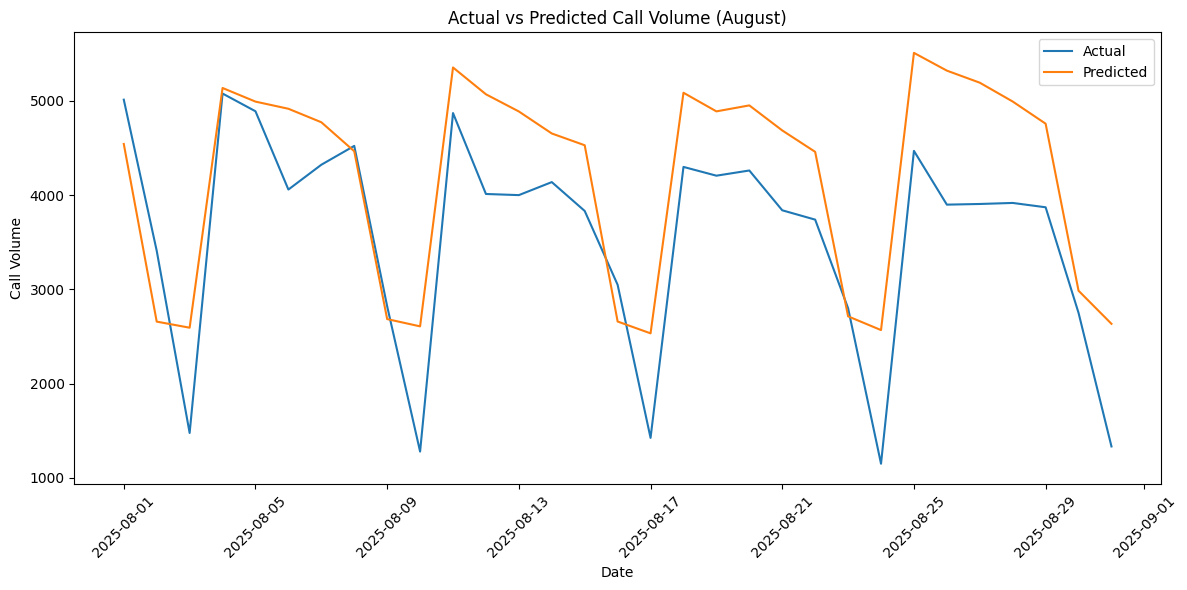

In [19]:
plt.figure(figsize=(12,6))

plt.plot(A_30min_pred_2["Date"], 
         A_30min_pred_2["Actual Daily Call Volume"], 
         label="Actual")

plt.plot(A_30min_pred_2["Date"], 
         A_30min_pred_2["Predicted Daily Call Volume"], 
         label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Call Volume (August)")
plt.xlabel("Date")
plt.ylabel("Call Volume")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Fit is much better.

### Switching Model for Better Fit Random Forest


### Random Forest


### Train Random Forest baseline


In [20]:
model_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

model_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### A Daily Test[RF Predicted Daily Call Volume]


In [21]:
A_Daily_Test["RF Predicted Daily Call Volume"] = model_rf.predict(X_test)
# Expand to 30-min level (same as before)
intervals = sorted(A_Interval["Interval"].unique())

A_30min_pred_rf = A_Daily_Test.loc[
    A_Daily_Test.index.repeat(len(intervals))
].copy()

A_30min_pred_rf["Interval"] = intervals * len(A_Daily_Test)
A_30min_pred_rf["weekday"] = A_30min_pred_rf["Date"].dt.dayofweek

# Map weights (reuse same pattern)
A_30min_pred_rf["weight"] = A_30min_pred_rf.set_index(
    ["weekday", "Interval"]
).index.map(pattern)

A_30min_pred_rf["weight"] = A_30min_pred_rf["weight"].fillna(0)

# Final 30-min predictions using RF
A_30min_pred_rf["Interval Prediction"] = (
    A_30min_pred_rf["RF Predicted Daily Call Volume"] *
    A_30min_pred_rf["weight"]
)

# 🔥 Final clean output (same structure)
A_30min_pred_3 = A_30min_pred_rf[[
    "Date",
    "Actual Daily Call Volume",
    "RF Predicted Daily Call Volume",
    "Interval",
    "Interval Prediction"
]]

### Compute model metrics


In [22]:
mse = mean_squared_error(
    A_30min_pred_3["Actual Daily Call Volume"],
    A_30min_pred_3["RF Predicted Daily Call Volume"]
)

print("MSE:", mse)
print("RMSE:", np.sqrt(mse))

MSE: 303975.58712096774
RMSE: 551.3398109342075


### Plot results


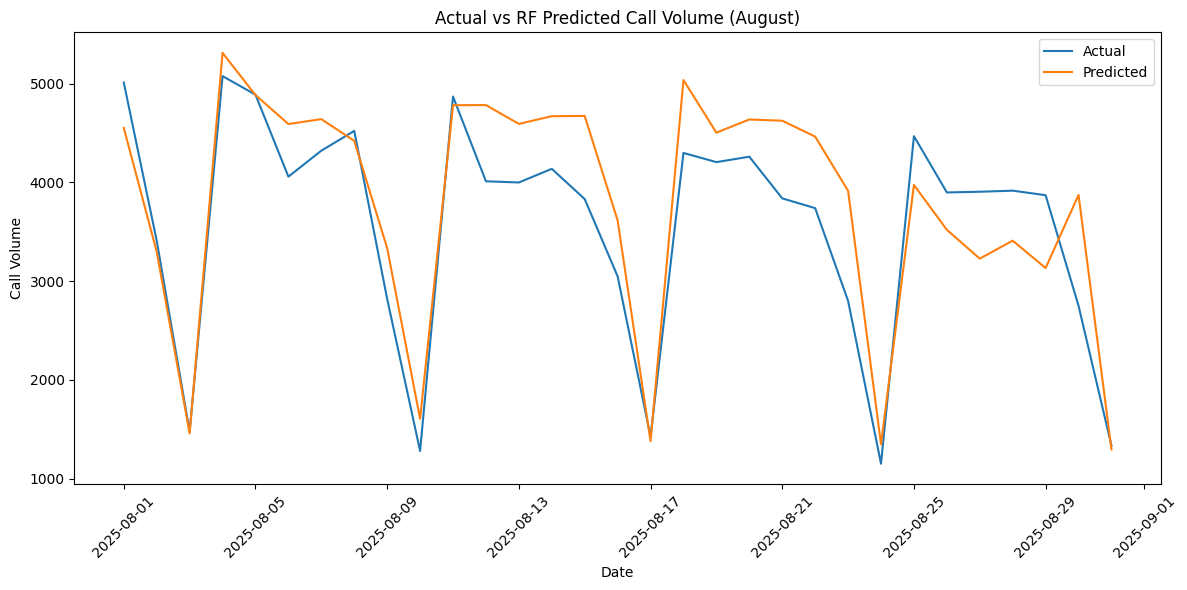

In [23]:
plt.figure(figsize=(12,6))

plt.plot(A_30min_pred_3["Date"], 
         A_30min_pred_3["Actual Daily Call Volume"], 
         label="Actual")

plt.plot(A_30min_pred_3["Date"], 
         A_30min_pred_3["RF Predicted Daily Call Volume"], 
         label="Predicted")

plt.legend()
plt.title("Actual vs RF Predicted Call Volume (August)")
plt.xlabel("Date")
plt.ylabel("Call Volume")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Gradient Boosting


### Train Gradient Boosting baseline


In [24]:
model_gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model_gb.fit(X_train, y_train)
A_Daily_Test["GB Predicted Daily Call Volume"] = model_gb.predict(X_test)

### Mse gb


In [25]:
mse_gb = mean_squared_error(
    A_Daily_Test["Actual Daily Call Volume"],
    A_Daily_Test["GB Predicted Daily Call Volume"]
)

print("Gradient Boosting MSE:", mse_gb)
print("RMSE:", np.sqrt(mse_gb))

Gradient Boosting MSE: 491771.2560151102
RMSE: 701.2640415814219


### Intervals


In [26]:
intervals = sorted(A_Interval["Interval"].unique())

A_30min_pred_gb = A_Daily_Test.loc[
    A_Daily_Test.index.repeat(len(intervals))
].copy()

A_30min_pred_gb["Interval"] = intervals * len(A_Daily_Test)
A_30min_pred_gb["weekday"] = A_30min_pred_gb["Date"].dt.dayofweek

A_30min_pred_gb["weight"] = A_30min_pred_gb.set_index(
    ["weekday", "Interval"]
).index.map(pattern)

A_30min_pred_gb["weight"] = A_30min_pred_gb["weight"].fillna(0)

A_30min_pred_gb["Interval Prediction"] = (
    A_30min_pred_gb["GB Predicted Daily Call Volume"] *
    A_30min_pred_gb["weight"]
)

A_30min_pred_4 = A_30min_pred_gb[[
    "Date",
    "Actual Daily Call Volume",
    "GB Predicted Daily Call Volume",
    "Interval",
    "Interval Prediction"
]]

### Plot results


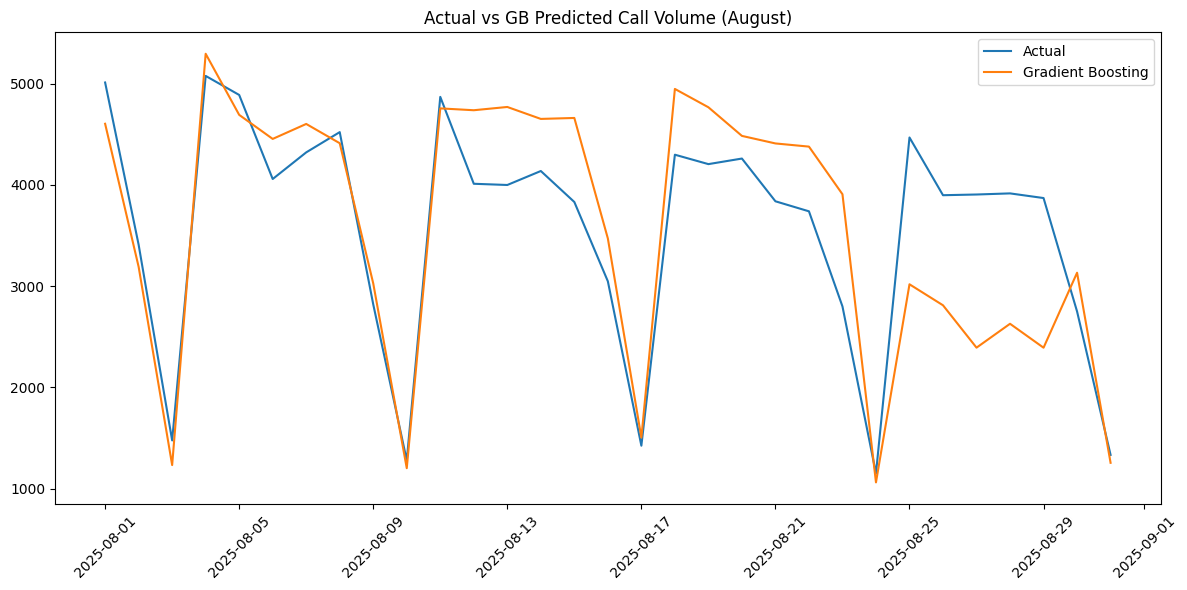

In [27]:

plt.figure(figsize=(12,6))

plt.plot(A_30min_pred_4["Date"],
         A_30min_pred_4["Actual Daily Call Volume"],
         label="Actual")

plt.plot(A_30min_pred_4["Date"],
         A_30min_pred_4["GB Predicted Daily Call Volume"],
         label="Gradient Boosting")

plt.legend()
plt.title("Actual vs GB Predicted Call Volume (August)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### XGBoost


### Train XGBoost model


In [28]:
model_xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### Train XGBoost model


In [29]:



A_Daily_Test["XGB Predicted Daily Call Volume"] = model_xgb.predict(X_test)
mse_xgb = mean_squared_error(
    A_Daily_Test["Actual Daily Call Volume"],
    A_Daily_Test["XGB Predicted Daily Call Volume"]
)

print("XGBoost MSE:", mse_xgb)

r2_xgb = r2_score(
    A_Daily_Test["Actual Daily Call Volume"],
    A_Daily_Test["XGB Predicted Daily Call Volume"]
)

print("XGBoost R^2:", r2_xgb)

rmse = np.sqrt(309273.53125)
print( "XGBoost RMSE:",rmse)

XGBoost MSE: 309273.53125
XGBoost R^2: 0.7614608407020569
XGBoost RMSE: 556.1236654288325


### Expand daily forecasts to 30-minute intervals


In [30]:
# Expand to 30-min level
intervals = sorted(A_Interval["Interval"].unique())

A_30min_pred_xgb = A_Daily_Test.loc[
    A_Daily_Test.index.repeat(len(intervals))
].copy()

A_30min_pred_xgb["Interval"] = intervals * len(A_Daily_Test)
A_30min_pred_xgb["weekday"] = A_30min_pred_xgb["Date"].dt.dayofweek

# Map weights
A_30min_pred_xgb["weight"] = A_30min_pred_xgb.set_index(
    ["weekday", "Interval"]
).index.map(pattern)

A_30min_pred_xgb["weight"] = A_30min_pred_xgb["weight"].fillna(0)

# Final 30-min prediction
A_30min_pred_xgb["Interval Prediction"] = (
    A_30min_pred_xgb["XGB Predicted Daily Call Volume"] *
    A_30min_pred_xgb["weight"]
)

# Final clean output
A_30min_pred_5 = A_30min_pred_xgb[[
    "Date",
    "Actual Daily Call Volume",
    "XGB Predicted Daily Call Volume",
    "Interval",
    "weight",
    "Interval Prediction"
]]
A_30min_pred_5["XGB Predicted Daily Call Volume"] = np.ceil(
    A_30min_pred_5["XGB Predicted Daily Call Volume"]
).astype(int)
A_30min_pred_5["Interval Prediction"] = np.ceil(
    A_30min_pred_5["Interval Prediction"]
).astype(int)

### Plot results


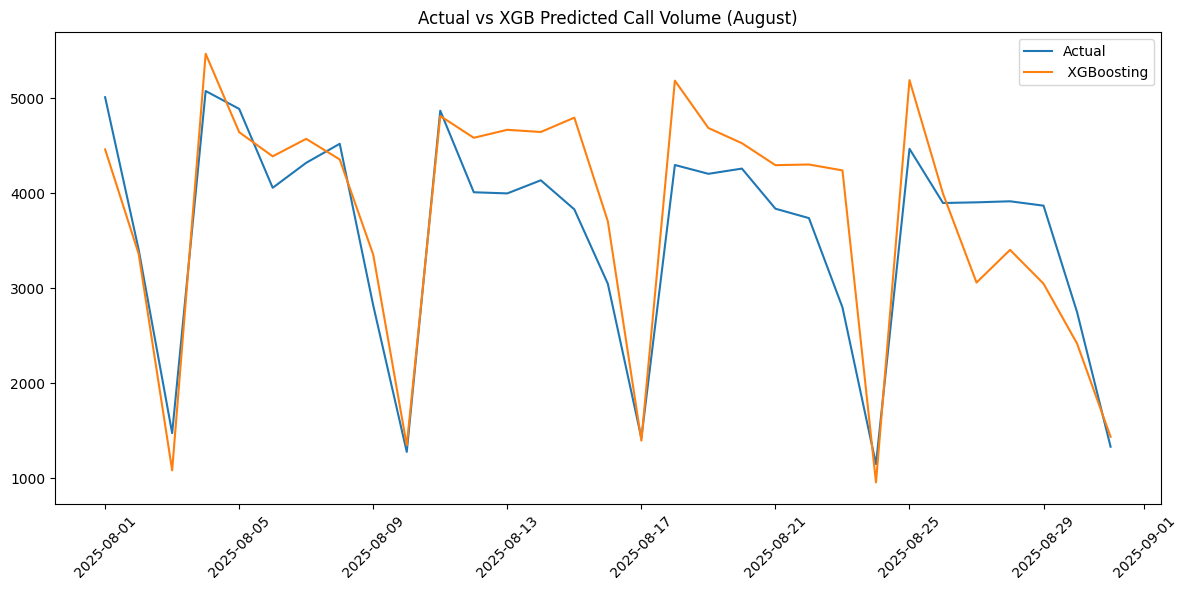

In [31]:

plt.figure(figsize=(12,6))

plt.plot(A_30min_pred_5["Date"],
         A_30min_pred_5["Actual Daily Call Volume"],
         label="Actual")

plt.plot(A_30min_pred_5["Date"],
         A_30min_pred_5["XGB Predicted Daily Call Volume"],
         label=" XGBoosting")

plt.legend()
plt.title("Actual vs XGB Predicted Call Volume (August)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Feature Engineering


##### With lag 1

### A Daily


In [32]:
A_Daily = A_Daily.sort_values("Date").reset_index(drop=True)
A_Daily["lag_1"] = A_Daily["Call Volume"].shift(1)
A_Daily["lag_7"] = A_Daily["Call Volume"].shift(7)
A_Daily["rolling_7"] = A_Daily["Call Volume"].rolling(7).mean()
A_Daily = A_Daily.dropna().copy()

### Create year-month column


In [33]:


# Create year-month column
A_Daily["year_month"] = A_Daily["Date"].dt.to_period("M")


# Split daily data
A_Daily_Train = A_Daily[A_Daily["year_month"] < "2025-08"].copy()
A_Daily_Test = A_Daily[A_Daily["year_month"] == "2025-08"].copy()

# Train daily regression
X_train = A_Daily_Train.drop(columns=["Date", "year_month", "Call Volume"])
y_train = A_Daily_Train["Call Volume"]



X_test = A_Daily_Test.drop(columns=["Date", "year_month", "Call Volume"])

model_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### Train XGBoost model


In [34]:

A_Daily_Test["XGB Predicted Daily Call Volume Lagged"] = model_xgb.predict(X_test)
mse_xgb_lagged = mean_squared_error(
    A_Daily_Test["Call Volume"],
    A_Daily_Test["XGB Predicted Daily Call Volume Lagged"]
)

print("XGBoost MSE Lagged:", mse_xgb_lagged)

r2_xgb_lagged = r2_score(
    A_Daily_Test["Call Volume"],
    A_Daily_Test["XGB Predicted Daily Call Volume Lagged"]
)

print("XGBoost R^2 Lagged:", r2_xgb_lagged)

rmse = np.sqrt(mse_xgb_lagged)
print( "XGBoost RMSE Lagged:",rmse)

XGBoost MSE Lagged: 392342.71875
XGBoost R^2 Lagged: 0.6973904967308044
XGBoost RMSE Lagged: 626.3726676268689


### Create weekly lag feature


In [35]:
print(A_Daily[["Call Volume", "lag_1", "lag_7"]].corr())

             Call Volume     lag_1     lag_7
Call Volume     1.000000  0.160387  0.795744
lag_1           0.160387  1.000000  0.119274
lag_7           0.795744  0.119274  1.000000


##### Lag 1 removed

### A Daily


In [36]:
A_Daily = A_Daily.sort_values("Date").reset_index(drop=True)

A_Daily["lag_7"] = A_Daily["Call Volume"].shift(7)
A_Daily["lag_14"] = A_Daily["Call Volume"].shift(14)
A_Daily["rolling_7"] = A_Daily["Call Volume"].rolling(7).mean()
A_Daily = A_Daily.drop(columns=["lag_1"])
A_Daily = A_Daily.dropna().copy()

### Create year-month column


In [37]:
# Create year-month column
A_Daily["year_month"] = A_Daily["Date"].dt.to_period("M")


# Split daily data
A_Daily_Train = A_Daily[A_Daily["year_month"] < "2025-08"].copy()
A_Daily_Test = A_Daily[A_Daily["year_month"] == "2025-08"].copy()

# Train daily regression
X_train = A_Daily_Train.drop(columns=["Date", "year_month", "Call Volume"])
y_train = A_Daily_Train["Call Volume"]



X_test = A_Daily_Test.drop(columns=["Date", "year_month", "Call Volume"])

model_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### Train XGBoost model


In [38]:
A_Daily_Test["XGB Predicted Daily Call Volume Lagged"] = model_xgb.predict(X_test)
mse_xgb_lagged = mean_squared_error(
    A_Daily_Test["Call Volume"],
    A_Daily_Test["XGB Predicted Daily Call Volume Lagged"]
)

print("XGBoost MSE Lagged:", mse_xgb_lagged)

r2_xgb_lagged = r2_score(
    A_Daily_Test["Call Volume"],
    A_Daily_Test["XGB Predicted Daily Call Volume Lagged"]
)

print("XGBoost R^2 Lagged:", r2_xgb_lagged)

rmse = np.sqrt(mse_xgb_lagged)
print( "XGBoost RMSE Lagged:",rmse)

XGBoost MSE Lagged: 267385.90625
XGBoost R^2 Lagged: 0.7937682867050171
XGBoost RMSE Lagged: 517.0937112845214


### Expand daily forecasts to 30-minute intervals


In [39]:
# Expand to 30-min level
intervals = sorted(A_Interval["Interval"].unique())

A_30min_pred_xgb_Lagged = A_Daily_Test.loc[
    A_Daily_Test.index.repeat(len(intervals))
].copy()

A_30min_pred_xgb_Lagged["Interval"] = intervals * len(A_Daily_Test)
A_30min_pred_xgb_Lagged["weekday"] = A_30min_pred_xgb_Lagged["Date"].dt.dayofweek

# Map weights
A_30min_pred_xgb_Lagged["weight"] = A_30min_pred_xgb_Lagged.set_index(
    ["weekday", "Interval"]
).index.map(pattern)

A_30min_pred_xgb_Lagged["weight"] = A_30min_pred_xgb_Lagged["weight"].fillna(0)

# Final 30-min prediction
A_30min_pred_xgb_Lagged["Interval Prediction"] = (
    A_30min_pred_xgb_Lagged["XGB Predicted Daily Call Volume Lagged"] *
    A_30min_pred_xgb_Lagged["weight"]
)

# Final clean output
A_30min_pred_6 = A_30min_pred_xgb_Lagged[[
    "Date",
    "Call Volume",
    "XGB Predicted Daily Call Volume Lagged",
    "Interval",
    "weight",
    "Interval Prediction"
]]
A_30min_pred_6["XGB Predicted Daily Call Volume Lagged"] = np.ceil(
    A_30min_pred_6["XGB Predicted Daily Call Volume Lagged"]
).astype(int)
A_30min_pred_6["Interval Prediction"] = np.ceil(
    A_30min_pred_6["Interval Prediction"]
).astype(int)

### Plot results


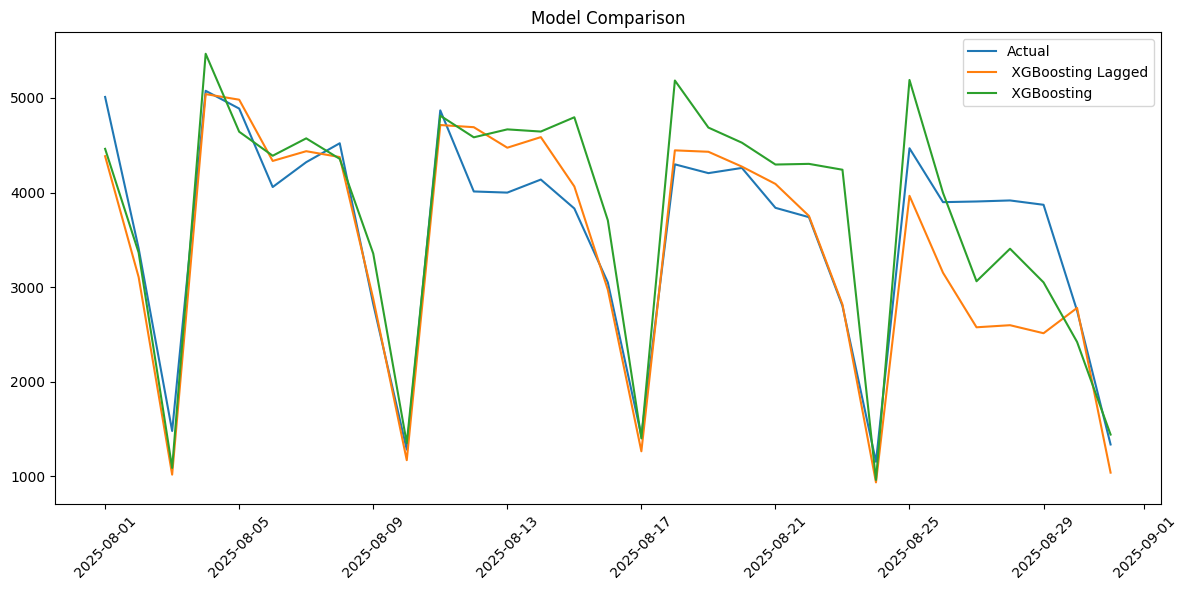

In [40]:

plt.figure(figsize=(12,6))

plt.plot(A_30min_pred_6["Date"],
         A_30min_pred_6["Call Volume"],
         label="Actual")

plt.plot(A_30min_pred_6["Date"],
         A_30min_pred_6["XGB Predicted Daily Call Volume Lagged"],
         label=" XGBoosting Lagged")

plt.plot(A_30min_pred_5["Date"],
         A_30min_pred_5["XGB Predicted Daily Call Volume"],
         label=" XGBoosting")
         

plt.legend()
plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Create longer lag features


In [41]:
A_Daily["lag_14"] = A_Daily["Call Volume"].shift(14)
print(A_Daily[["Call Volume", "lag_14"]].corr())

             Call Volume    lag_14
Call Volume     1.000000  0.751924
lag_14          0.751924  1.000000


### XGBoost baselines
Uses clean daily call volumes to build baseline and lagged XGB models, then fans predictions down to 30-minute intervals using historical interval weights. Features include day-of-week, weekend flag, and optional lags/rolling means.


### XGBoost pipelines for all service groups


Service Group A
XGBoost: {'mse': 250907.921875, 'rmse': np.float64(500.9070990463202), 'r2': 0.8064775466918945}
XGBoost Lagged: {'mse': 258357.109375, 'rmse': np.float64(508.2884116080161), 'r2': 0.8007320761680603}


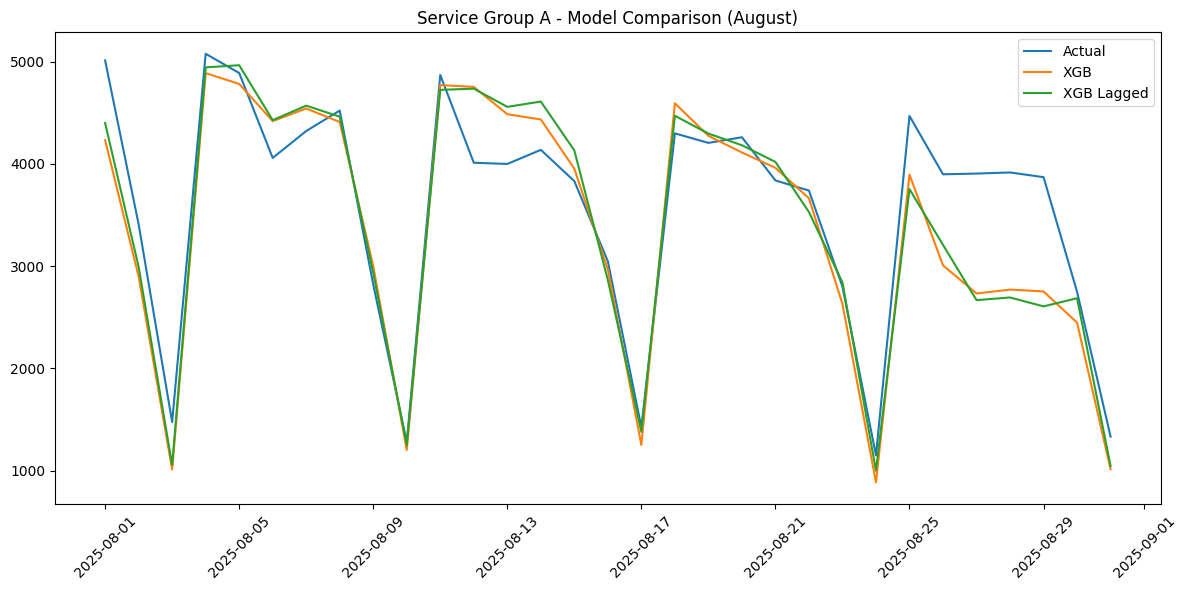

Service Group B
XGBoost: {'mse': 1749153.75, 'rmse': np.float64(1322.5557644197843), 'r2': 0.6703265309333801}
XGBoost Lagged: {'mse': 1207942.25, 'rmse': np.float64(1099.0642610875855), 'r2': 0.772331953048706}


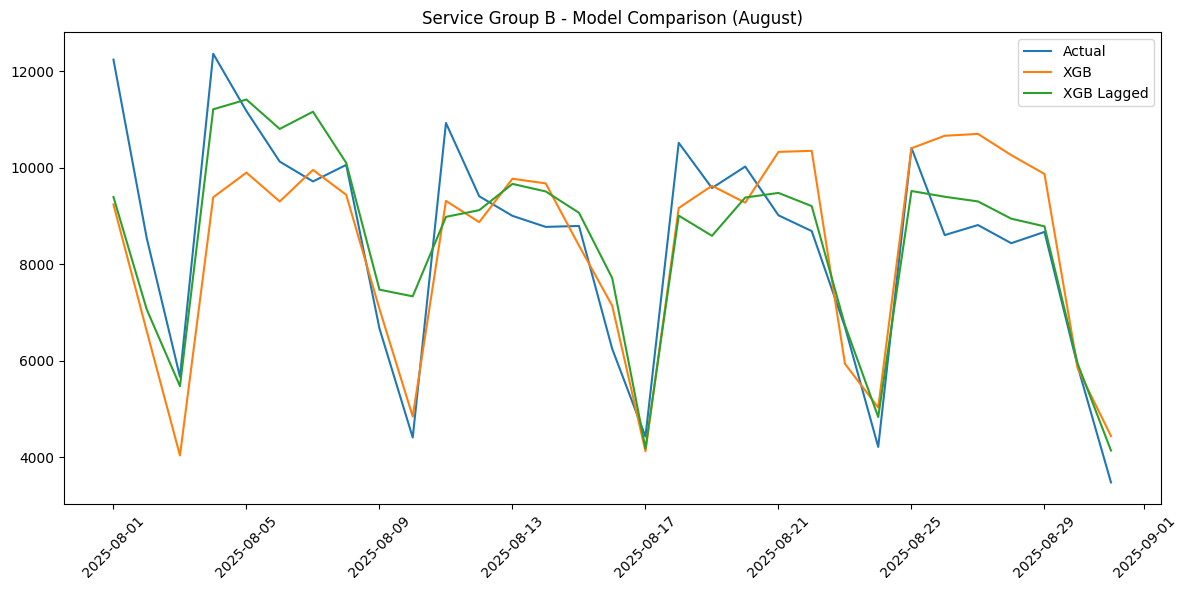

Service Group C
XGBoost: {'mse': 3730098.632743105, 'rmse': np.float64(1931.3463264632537), 'r2': 0.8552902898529814}
XGBoost Lagged: {'mse': 1126399.0670018657, 'rmse': np.float64(1061.3194933675088), 'r2': 0.9563011870343381}


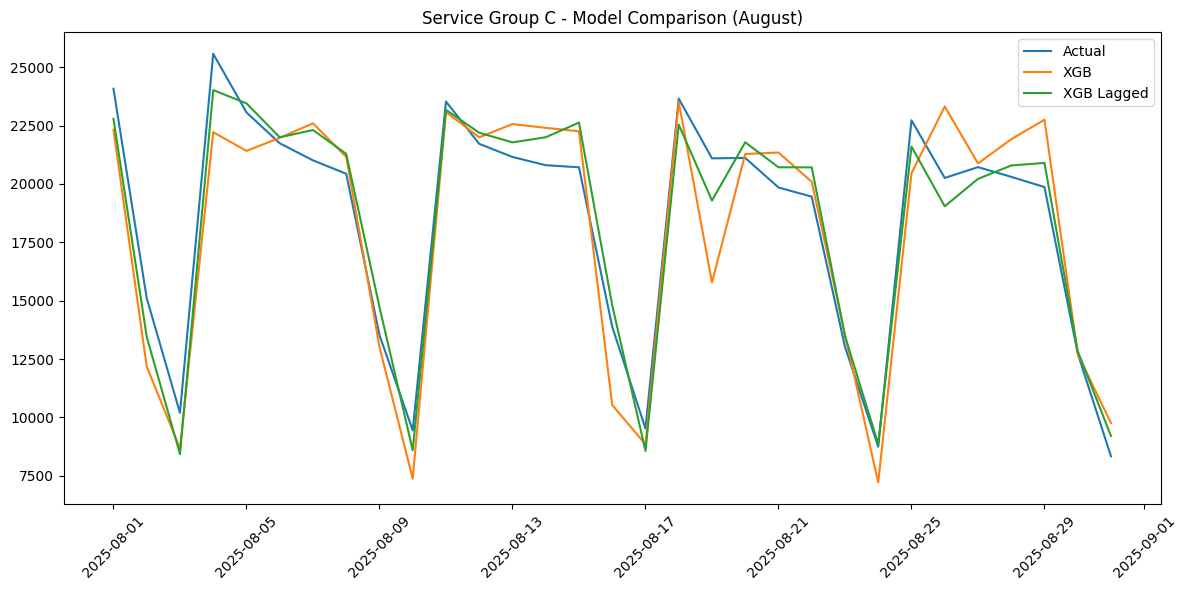

Service Group D
XGBoost: {'mse': 1654912.1147673693, 'rmse': np.float64(1286.4338750077166), 'r2': 0.7006322312013339}
XGBoost Lagged: {'mse': 1228689.2435698954, 'rmse': np.float64(1108.4625584880598), 'r2': 0.777734446372008}


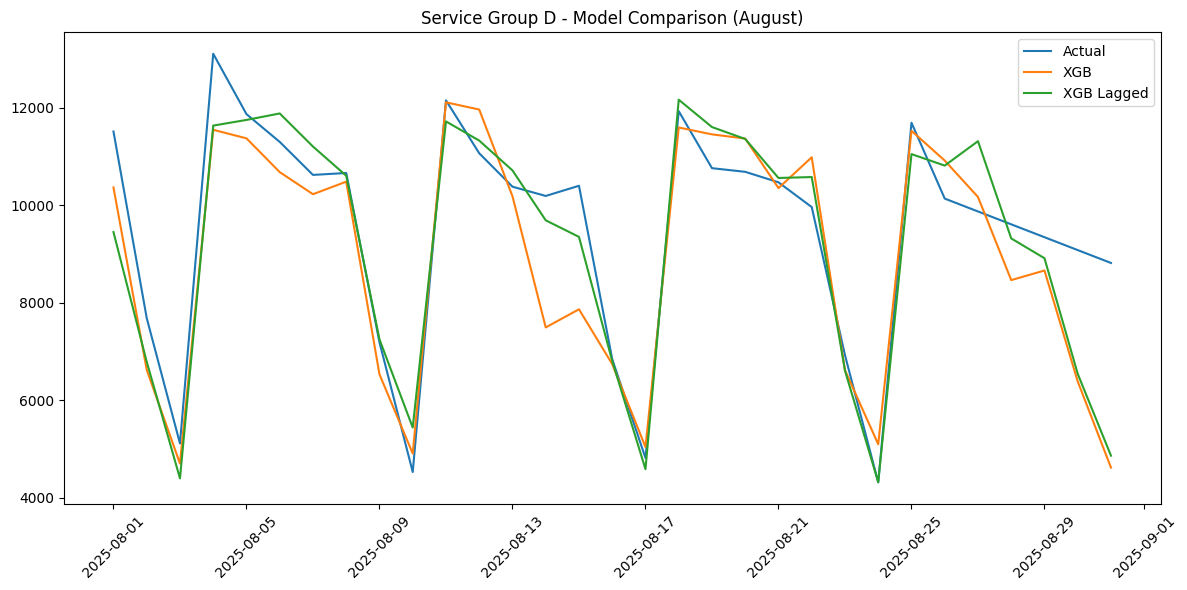

In [42]:

# Predict call volume for Service Groups A, B, C, and D
# - Baseline XGB and lagged-feature XGB
# - 30-min expansion using group-specific interval patterns
# - Export August interval-level predictions to CSV
# - Show per-group model comparison plots


def _build_pattern(interval_df):
    df = interval_df.copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df["weekday"] = df["Date"].dt.dayofweek
    df = df.dropna(subset=["Call Volume", "Interval"])

    pattern = df.groupby(["weekday", "Interval"])["Call Volume"].mean()
    pattern = pattern / pattern.groupby(level=0).sum()

    intervals = sorted(df["Interval"].dropna().unique().tolist())
    return pattern, intervals


def _fit_xgb_daily(daily_df, *, pred_col, model_params, add_lags):
    df = daily_df.copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    df["Call Volume"] = pd.to_numeric(df["Call Volume"], errors="coerce")
    df = df.dropna(subset=["Call Volume"]).copy()

    df["dayofweek"] = df["Date"].dt.dayofweek
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

    if add_lags:
        df["lag_7"] = df["Call Volume"].shift(7)
        df["lag_14"] = df["Call Volume"].shift(14)
        df["rolling_7"] = df["Call Volume"].rolling(7).mean()
        df = df.dropna().copy()

    df["year_month"] = df["Date"].dt.to_period("M")
    train_df = df[df["year_month"] < "2025-08"].copy()
    test_df = df[df["year_month"] == "2025-08"].copy()

    X_train = train_df.drop(columns=["Date", "year_month", "Call Volume"])
    y_train = train_df["Call Volume"]
    X_test = test_df.drop(columns=["Date", "year_month", "Call Volume"])

    model = XGBRegressor(**model_params)
    model.fit(X_train, y_train)

    test_df[pred_col] = model.predict(X_test)

    mse = mean_squared_error(test_df["Call Volume"], test_df[pred_col])
    r2 = r2_score(test_df["Call Volume"], test_df[pred_col])
    rmse = np.sqrt(mse)

    return test_df, {"mse": mse, "rmse": rmse, "r2": r2}


def _expand_to_30min(daily_test_df, *, intervals, pattern, pred_col):
    df = daily_test_df.loc[daily_test_df.index.repeat(len(intervals))].copy()
    df["Interval"] = intervals * len(daily_test_df)
    df["weekday"] = df["Date"].dt.dayofweek

    df["weight"] = df.set_index(["weekday", "Interval"]).index.map(pattern)
    df["weight"] = df["weight"].fillna(0)

    df["Interval Prediction"] = df[pred_col] * df["weight"]

    out = df[["Date", "Call Volume", pred_col, "Interval", "weight", "Interval Prediction"]].copy()
    out[pred_col] = np.ceil(out[pred_col]).astype(int)
    out["Interval Prediction"] = np.ceil(out["Interval Prediction"]).astype(int)
    return out


def run_group(group_label, daily_df, interval_df):
    pattern, intervals = _build_pattern(interval_df)

    base_params = dict(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
    )
    lag_params = dict(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
    )

    test_base, metrics_base = _fit_xgb_daily(
        daily_df,
        pred_col="XGB Predicted Daily Call Volume",
        model_params=base_params,
        add_lags=False,
    )
    pred_base_30 = _expand_to_30min(
        test_base,
        intervals=intervals,
        pattern=pattern,
        pred_col="XGB Predicted Daily Call Volume",
    )

    test_lag, metrics_lag = _fit_xgb_daily(
        daily_df,
        pred_col="XGB Predicted Daily Call Volume Lagged",
        model_params=lag_params,
        add_lags=True,
    )
    pred_lag_30 = _expand_to_30min(
        test_lag,
        intervals=intervals,
        pattern=pattern,
        pred_col="XGB Predicted Daily Call Volume Lagged",
    )

    print(f"Service Group {group_label}")
    print("XGBoost:", metrics_base)
    print("XGBoost Lagged:", metrics_lag)

    # Plot daily comparison (August only)
    plot_base = pred_base_30.drop_duplicates("Date").sort_values("Date")
    plot_lag = pred_lag_30.drop_duplicates("Date").sort_values("Date")

    plt.figure(figsize=(12, 6))
    plt.plot(plot_base["Date"], plot_base["Call Volume"], label="Actual")
    plt.plot(plot_base["Date"], plot_base["XGB Predicted Daily Call Volume"], label="XGB")
    plt.plot(plot_lag["Date"], plot_lag["XGB Predicted Daily Call Volume Lagged"], label="XGB Lagged")
    plt.legend()
    plt.title(f"Service Group {group_label} - Model Comparison (August)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return pred_base_30, pred_lag_30


def _prepare_export(group_label, base_df, lag_df):
    merged = base_df.merge(
        lag_df[["Date", "Interval", "Interval Prediction", "XGB Predicted Daily Call Volume Lagged"]],
        on=["Date", "Interval"],
        how="left",
        suffixes=("", "_lagged_only"),
    )

    merged = merged.rename(
        columns={
            "Call Volume": f"Call Volume {group_label}",
            "XGB Predicted Daily Call Volume": f"{group_label} Daily XGB",
            "Interval Prediction": f"{group_label} Interval XGB",
            "Interval Prediction_lagged_only": f"{group_label} Interval XGB Lagged",
            "XGB Predicted Daily Call Volume Lagged": f"{group_label} Daily XGB Lagged",
        }
    )

    merged["Service Group"] = group_label
    return merged


# Run all service groups
A_30min_pred_5, A_30min_pred_6 = run_group("A", A_Daily, A_Interval)
B_30min_pred_5, B_30min_pred_6 = run_group("B", B_Daily, B_Interval)
C_30min_pred_5, C_30min_pred_6 = run_group("C", C_Daily, C_Interval)
D_30min_pred_5, D_30min_pred_6 = run_group("D", D_Daily, D_Interval)

# Export interval-level predictions for August (all groups)
export_frames = [
    _prepare_export("A", A_30min_pred_5, A_30min_pred_6),
    _prepare_export("B", B_30min_pred_5, B_30min_pred_6),
    _prepare_export("C", C_30min_pred_5, C_30min_pred_6),
    _prepare_export("D", D_30min_pred_5, D_30min_pred_6),
]

august_interval_predictions = pd.concat(export_frames, ignore_index=True)
august_interval_predictions = august_interval_predictions[
    august_interval_predictions["Date"].dt.month == 8
].copy()

# keep only interval-level predictions (no daily totals)
interval_cols = ["Date", "Interval", "Service Group"]
interval_cols += [c for c in august_interval_predictions.columns if "Interval XGB" in c]
august_interval_predictions = august_interval_predictions[interval_cols]





### Neural Net


### HistGradientBoosting
Gradient-boosted trees with early stopping, log1p targets, quantile clipping, calendar+lag features, and interval expansion. Serves as an alternative boosting method to compare with XGB.


### Train Gradient Boosting baseline


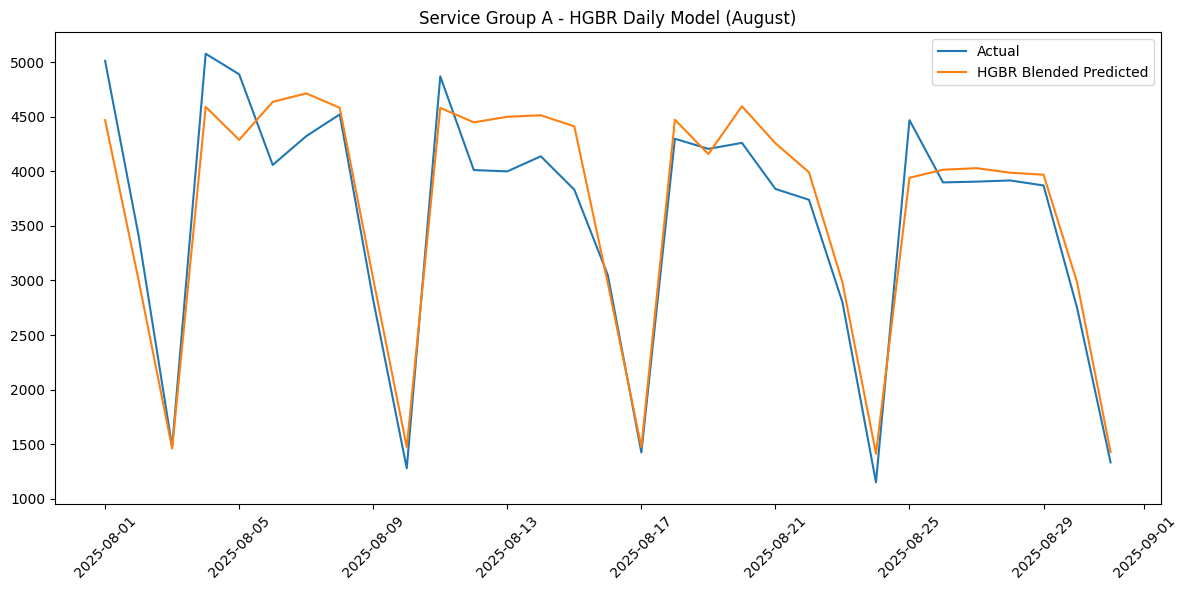

HGBR metrics (A): MSE=113018.90, RMSE=336.18, R2=0.913, alpha=0.96


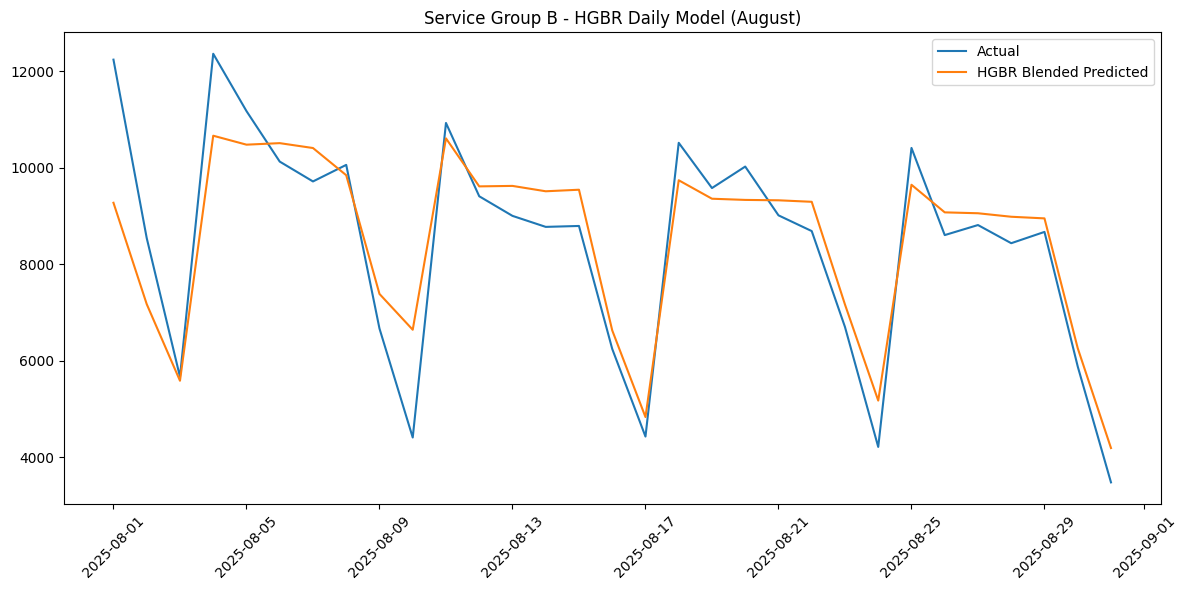

HGBR metrics (B): MSE=863118.88, RMSE=929.04, R2=0.837, alpha=0.98


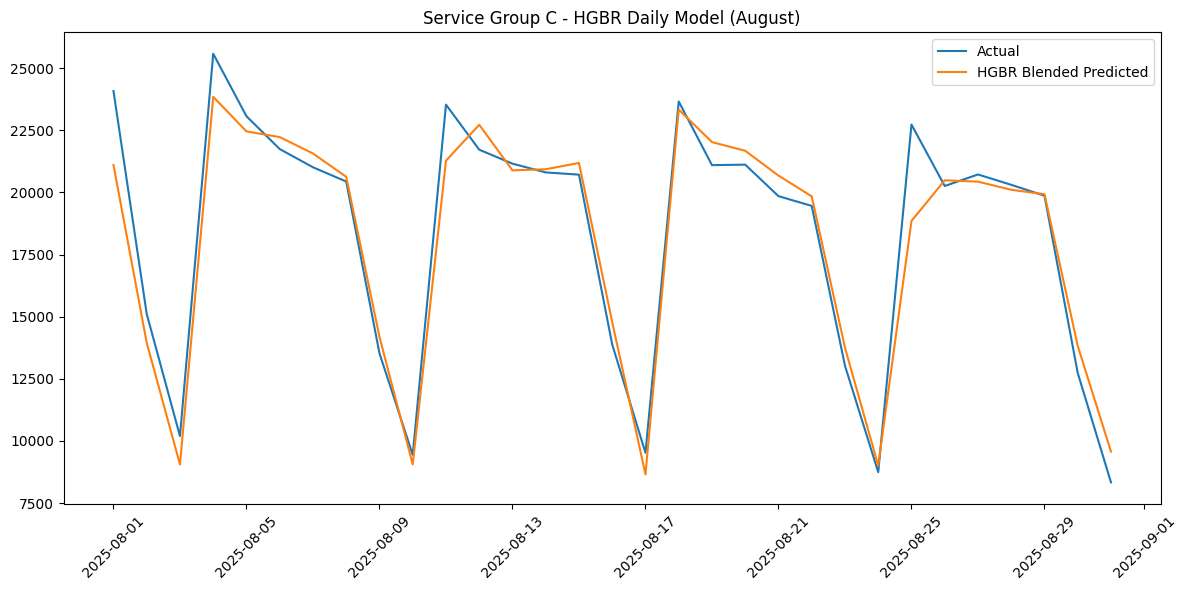

HGBR metrics (C): MSE=1440101.75, RMSE=1200.04, R2=0.944, alpha=0.98


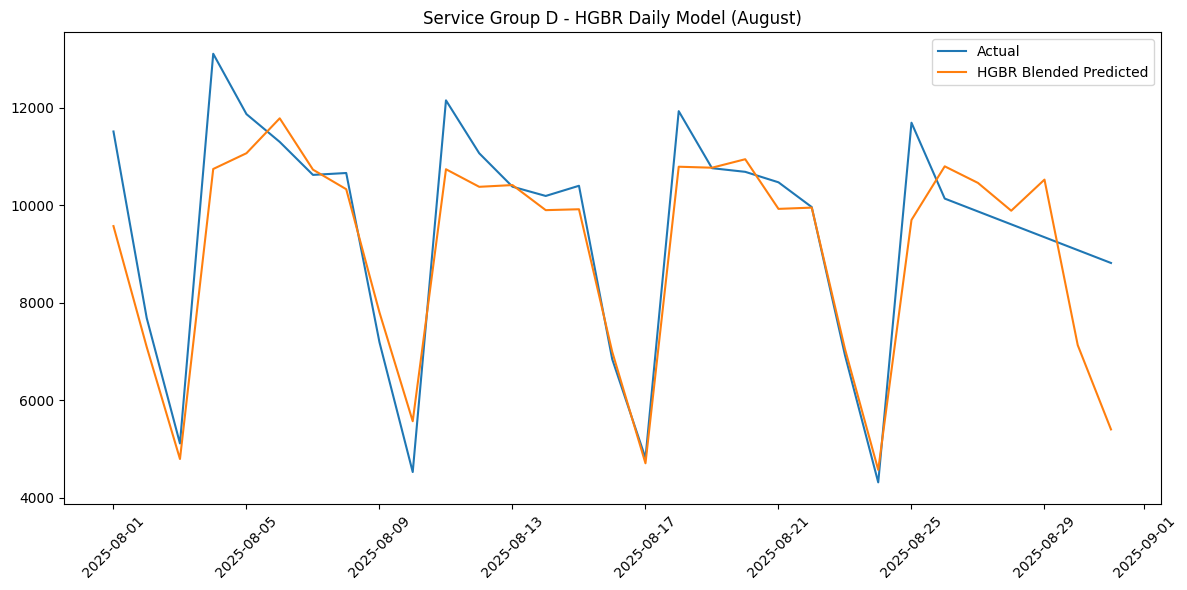

HGBR metrics (D): MSE=1243909.58, RMSE=1115.31, R2=0.775, alpha=0.90


In [43]:

# Iterative Boosting Alternative (HistGradientBoostingRegressor)
# - Tree-based boosting that improves over iterations (not XGBoost)
# - Uses engineered calendar/lag features, log1p target, early stopping
# - Blends with rolling_7 baseline, plots per group, exports August intervals

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score


def _prepare_daily_hgbr(daily_df):
    df = daily_df.copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    df["Call Volume"] = pd.to_numeric(df["Call Volume"], errors="coerce")
    df["dayofweek"] = df["Date"].dt.dayofweek
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
    df["month"] = df["Date"].dt.month
    df["weekofyear"] = df["Date"].dt.isocalendar().week.astype(int)
    df["dayofyear"] = df["Date"].dt.dayofyear
    df["trend"] = np.arange(len(df))
    df["sin_doy"] = np.sin(2 * np.pi * df["dayofyear"] / 365.25)
    df["cos_doy"] = np.cos(2 * np.pi * df["dayofyear"] / 365.25)
    df["lag_7"] = df["Call Volume"].shift(7)
    df["lag_14"] = df["Call Volume"].shift(14)
    df["lag_21"] = df["Call Volume"].shift(21)
    df["rolling_7"] = df["Call Volume"].rolling(7).mean()
    df["rolling_14"] = df["Call Volume"].rolling(14).mean()
    df = df.dropna().copy()
    df["year_month"] = df["Date"].dt.to_period("M")
    return df


def _build_pattern(interval_df):
    df = interval_df.copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df["weekday"] = df["Date"].dt.dayofweek
    df = df.dropna(subset=["Call Volume", "Interval"])
    pattern = df.groupby(["weekday", "Interval"])["Call Volume"].mean()
    pattern = pattern / pattern.groupby(level=0).sum()
    intervals = sorted(df["Interval"].dropna().unique().tolist())
    return pattern, intervals


def _blend_with_baseline(pred, baseline, y_true):
    best_alpha, best_mse = 1.0, float("inf")
    for a in np.linspace(0.80, 0.98, 10):
        mix = a * pred + (1 - a) * baseline
        mse = mean_squared_error(y_true, mix)
        if mse < best_mse:
            best_mse, best_alpha = mse, a
    return best_alpha


def run_hgbr_group(group_label, daily_df, interval_df):
    df = _prepare_daily_hgbr(daily_df)
    clip_val = df["Call Volume"].quantile(0.995)
    df["Call Volume"] = df["Call Volume"].clip(upper=clip_val)

    train_df = df[df["year_month"] < "2025-08"].copy()
    test_df = df[df["year_month"] == "2025-08"].copy()

    X_cols = [c for c in train_df.columns if c not in ["Date", "year_month", "Call Volume"]]
    X_train = train_df[X_cols].values
    y_train = np.log1p(train_df["Call Volume"].values)
    X_test = test_df[X_cols].values
    y_test = test_df["Call Volume"].values

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    val_days = min(30, max(1, len(X_train_s) // 5))
    X_tr, X_va = X_train_s[:-val_days], X_train_s[-val_days:]
    y_tr, y_va = y_train[:-val_days], y_train[-val_days:]
    roll_va = train_df.iloc[-val_days:]["rolling_7"].values

    hgbr = HistGradientBoostingRegressor(
        learning_rate=0.03,
        max_depth=7,
        max_leaf_nodes=63,
        min_samples_leaf=5,
        l2_regularization=5e-3,
        loss="squared_error",
        early_stopping=True,
        validation_fraction=0.20,
        n_iter_no_change=50,
        max_iter=1200,
        random_state=42,
    )
    hgbr.fit(X_tr, y_tr)

    val_pred_nn = np.expm1(hgbr.predict(X_va))
    alpha = _blend_with_baseline(val_pred_nn, roll_va, np.expm1(y_va))

    test_pred_nn = np.expm1(hgbr.predict(X_test_s))
    test_pred = alpha * test_pred_nn + (1 - alpha) * test_df["rolling_7"].values
    test_pred = np.clip(test_pred, 0, None)

    test_df = test_df.copy()
    test_df["HGBR Predicted Daily Call Volume"] = test_pred

    mse = mean_squared_error(y_test, test_pred)
    r2 = r2_score(y_test, test_pred)
    rmse = np.sqrt(mse)

    pattern, intervals = _build_pattern(interval_df)
    hgbr_30min = test_df.loc[test_df.index.repeat(len(intervals))].copy()
    hgbr_30min["Interval"] = intervals * len(test_df)
    hgbr_30min["weekday"] = hgbr_30min["Date"].dt.dayofweek
    hgbr_30min["weight"] = hgbr_30min.set_index(["weekday", "Interval"]).index.map(pattern).fillna(0)
    hgbr_30min["Interval Prediction"] = hgbr_30min["HGBR Predicted Daily Call Volume"] * hgbr_30min["weight"]
    hgbr_30min = hgbr_30min[["Date", "Call Volume", "HGBR Predicted Daily Call Volume", "Interval", "weight", "Interval Prediction"]]
    hgbr_30min["HGBR Predicted Daily Call Volume"] = np.ceil(hgbr_30min["HGBR Predicted Daily Call Volume"]).astype(int)
    hgbr_30min["Interval Prediction"] = np.ceil(hgbr_30min["Interval Prediction"]).astype(int)

    plt.figure(figsize=(12, 6))
    plt.plot(test_df["Date"], y_test, label="Actual")
    plt.plot(test_df["Date"], test_pred, label="HGBR Blended Predicted")
    plt.legend()
    plt.title(f"Service Group {group_label} - HGBR Daily Model (August)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print(f"HGBR metrics ({group_label}): MSE={mse:.2f}, RMSE={rmse:.2f}, R2={r2:.3f}, alpha={alpha:.2f}")
    return test_df, hgbr_30min, {"mse": mse, "rmse": rmse, "r2": r2, "alpha": alpha}


# Run for all service groups
hgbr_group_data = {
    "A": (A_Daily, A_Interval),
    "B": (B_Daily, B_Interval),
    "C": (C_Daily, C_Interval),
    "D": (D_Daily, D_Interval),
}

hgbr_exports = []
hgbr_metrics = {}
for g, (daily_df, interval_df) in hgbr_group_data.items():
    daily_pred, interval_pred, metrics = run_hgbr_group(g, daily_df, interval_df)
    interval_pred = interval_pred.rename(columns={
        "Call Volume": f"Call Volume {g}",
        "HGBR Predicted Daily Call Volume": f"{g} Daily HGBR",
        "Interval Prediction": f"{g} Interval HGBR",
    })
    interval_pred["Service Group"] = g
    hgbr_exports.append(interval_pred)
    hgbr_metrics[g] = metrics

august_hgbr_predictions = pd.concat(hgbr_exports, ignore_index=True)
august_hgbr_predictions = august_hgbr_predictions[august_hgbr_predictions["Date"].dt.month == 8].copy()

# keep only interval-level predictions (no daily totals)
interval_cols = ["Date", "Interval", "Service Group"]
interval_cols += [c for c in august_hgbr_predictions.columns if "Interval HGBR" in c]
august_hgbr_predictions = august_hgbr_predictions[interval_cols]





### Daily comparison: Actual vs XGB lagged vs HGBR


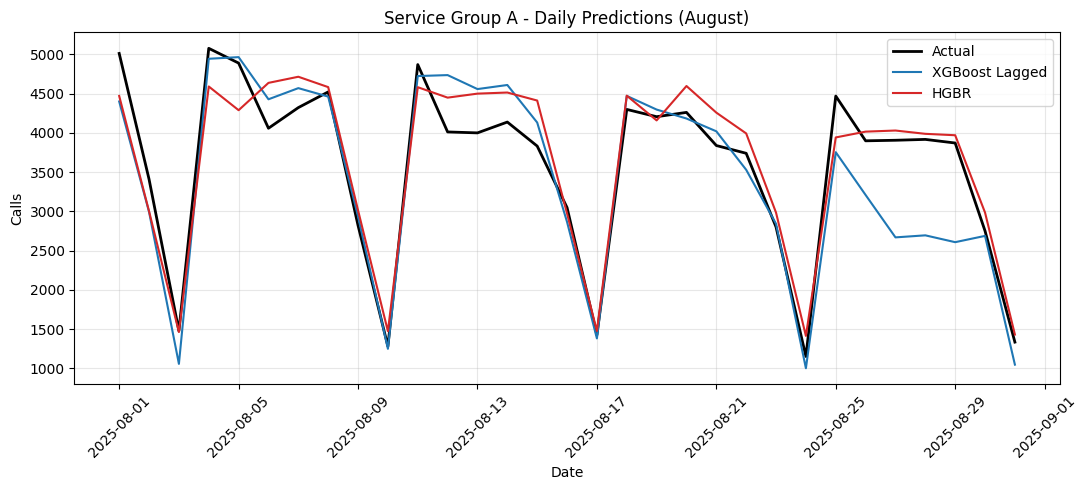

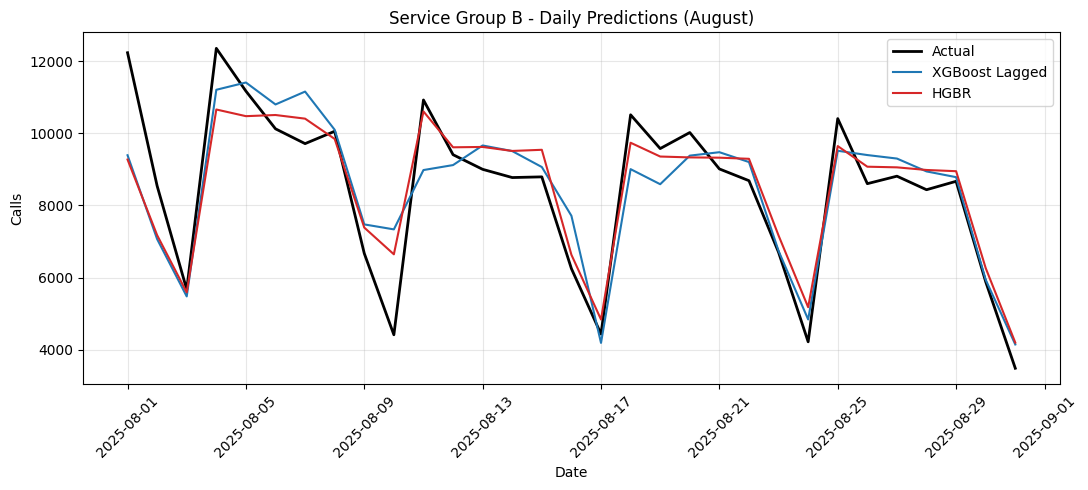

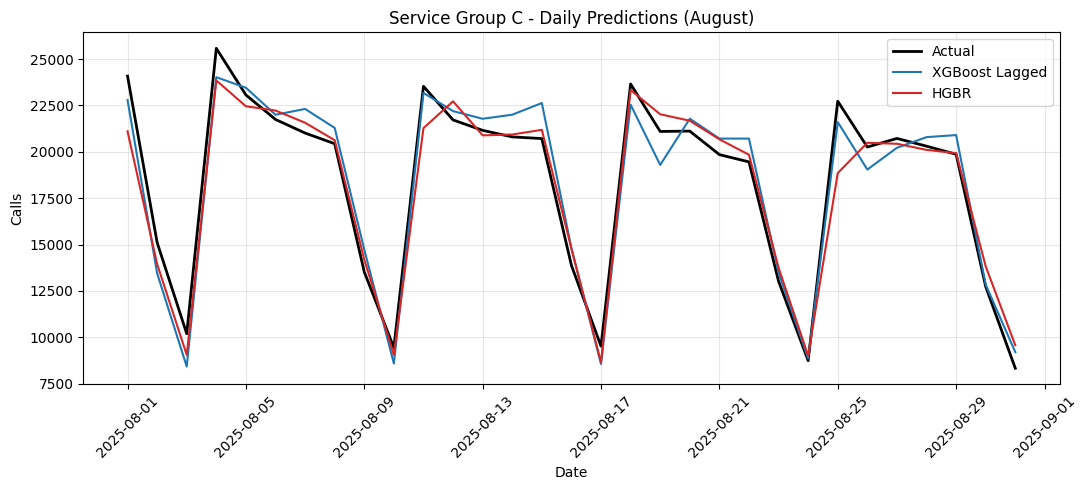

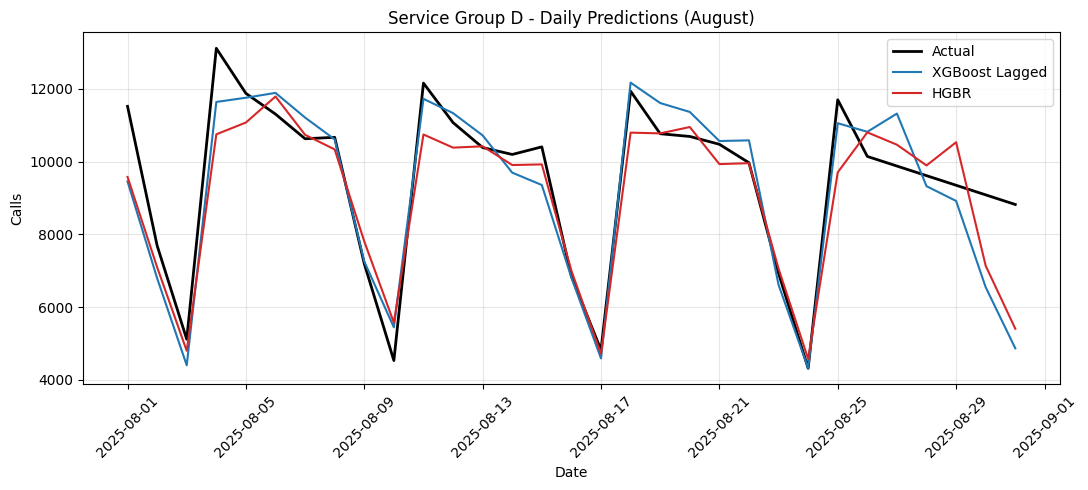

In [44]:

# Plots: Actual vs XGBoost Lagged vs HGBR (August, per service group)
import matplotlib.pyplot as plt
import pandas as pd

groups = ["A", "B", "C", "D"]

hgbr_by_group = {df["Service Group"].iloc[0]: df for df in hgbr_exports}
xgb_lagged_by_group = {
    "A": A_30min_pred_6,
    "B": B_30min_pred_6,
    "C": C_30min_pred_6,
    "D": D_30min_pred_6,
}

for g in groups:
    h_df = hgbr_by_group[g].drop_duplicates("Date").copy()
    x_df = xgb_lagged_by_group[g].drop_duplicates("Date").copy()

    dates = pd.to_datetime(h_df["Date"])
    # actual from HGBR frame (already renamed)
    actual_col = f"Call Volume {g}"
    actual = h_df[actual_col] if actual_col in h_df.columns else x_df["Call Volume"]

    xgb_pred_col = "XGB Predicted Daily Call Volume Lagged"
    xgb_pred = x_df[xgb_pred_col] if xgb_pred_col in x_df.columns else x_df[f"{g} Daily XGB Lagged"]
    hgbr_pred = h_df[f"{g} Daily HGBR"]

    plt.figure(figsize=(11,5))
    plt.plot(dates, actual, label="Actual", color="black", linewidth=2)
    plt.plot(dates, xgb_pred, label="XGBoost Lagged", color="#1f77b4")
    plt.plot(dates, hgbr_pred, label="HGBR", color="#d62728")
    plt.title(f"Service Group {g} - Daily Predictions (August)")
    plt.xlabel("Date")
    plt.ylabel("Calls")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.grid(alpha=0.3)
    plt.show()



### Combined interval predictions
Merges the two best interval predictors into one wide table, deduping by Date/Interval so each interval/day has one row with all service-group predictions.


### Combined interval predictions (XGB lagged + HGBR)


In [45]:

# Combine XGB Lagged + HGBR interval predictions into one wide CSV (Aug only)
# Run after XGB and HGBR cells
import pandas as pd

# Build XGB wide from export_frames (already renamed with group labels)
xgb_all = pd.concat(export_frames, ignore_index=True)
xgb_all = xgb_all[xgb_all["Date"].dt.month == 8].copy()
xgb_cols = ["Date", "Interval"] + [c for c in xgb_all.columns if "Interval XGB" in c]
xgb_all = xgb_all[xgb_cols]
# ensure one row per Date/Interval
xgb_all = (xgb_all
    .sort_values(["Date", "Interval"])
    .groupby(["Date", "Interval"], as_index=False)
    .first()
)

# Build HGBR wide from hgbr_exports
hgbr_all = pd.concat(hgbr_exports, ignore_index=True)
hgbr_all = hgbr_all[hgbr_all["Date"].dt.month == 8].copy()
hgbr_cols = ["Date", "Interval"] + [c for c in hgbr_all.columns if "Interval HGBR" in c]
hgbr_all = hgbr_all[hgbr_cols]
hgbr_all = (hgbr_all
    .sort_values(["Date", "Interval"])
    .groupby(["Date", "Interval"], as_index=False)
    .first()
)

combined = xgb_all.merge(hgbr_all, on=["Date", "Interval"], how="outer")
combined = (combined
    .sort_values(["Date", "Interval"])
    .groupby(["Date", "Interval"], as_index=False)
    .first()
)

# Order columns Date, Interval, XGB A-D, HGBR A-D if present
xgb_order = [c for c in ["A Interval XGB", "A Interval XGB Lagged", "B Interval XGB", "B Interval XGB Lagged", "C Interval XGB", "C Interval XGB Lagged", "D Interval XGB", "D Interval XGB Lagged"] if c in combined.columns]
hgbr_order = [c for c in ["A Interval HGBR", "B Interval HGBR", "C Interval HGBR", "D Interval HGBR"] if c in combined.columns]
col_order = ["Date", "Interval"] + xgb_order + hgbr_order
combined = combined[col_order]

combined.to_csv("august_interval_predictions_combined.csv", index=False)
print("Saved combined interval predictions to august_interval_predictions_combined.csv")



Saved combined interval predictions to august_interval_predictions_combined.csv


### Learning-rate sweep — XGBoost lagged
Runs the lagged XGB daily model across multiple learning rates, reports metrics, and plots the best curve per service group.

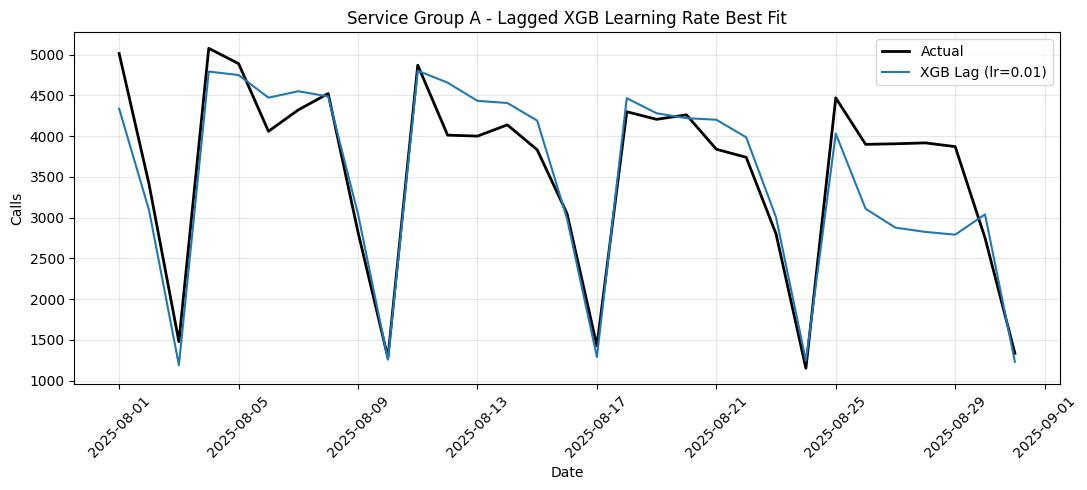

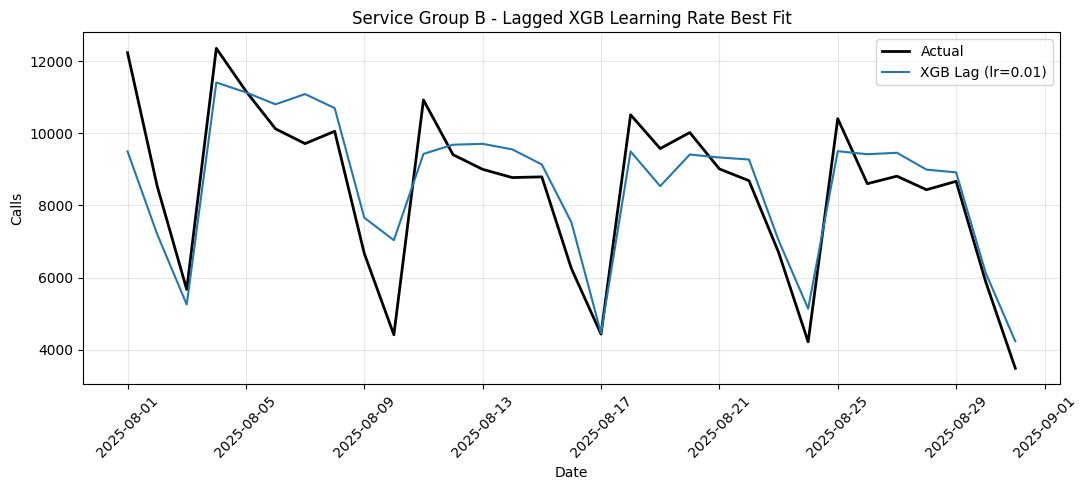

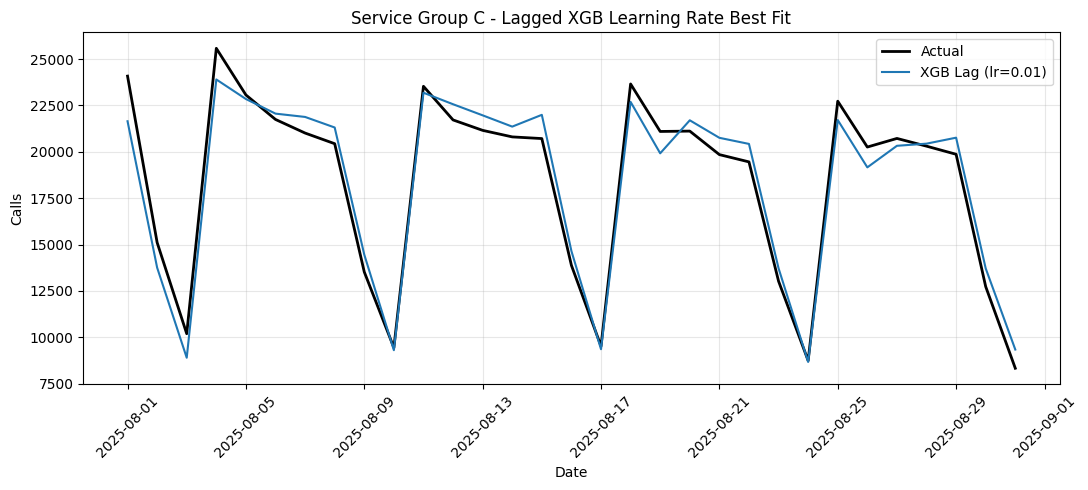

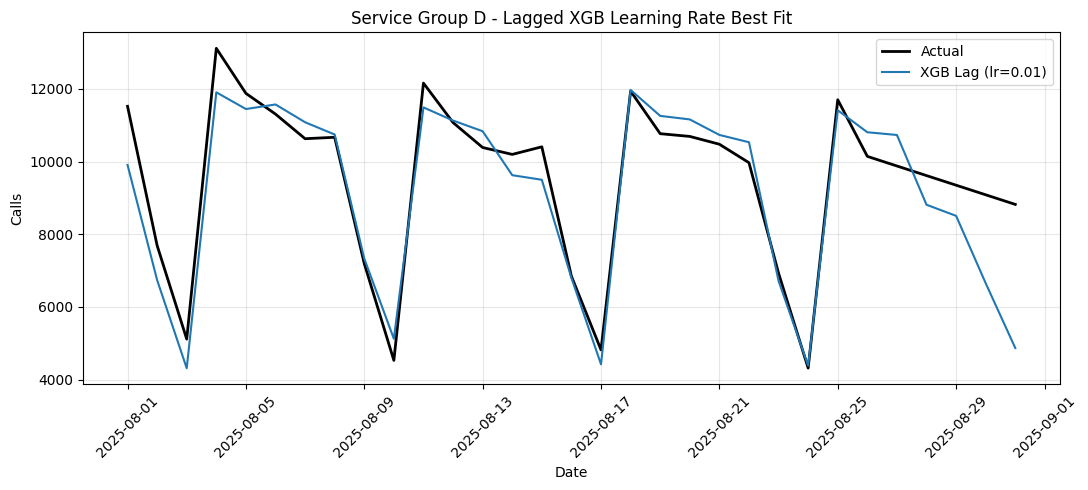

,group,lr,mse,rmse,r2
0,A,0.01,2.081076e+05,456.188078,0.839489
1,A,0.03,2.898281e+05,538.356846,0.776459
2,A,0.05,2.583571e+05,508.288412,0.800732
3,A,0.10,2.498461e+05,499.846039,0.807297
4,B,0.01,1.063513e+06,1031.267788,0.799553
5,B,0.03,1.214125e+06,1101.873405,0.771167
6,B,0.05,1.207942e+06,1099.064261,0.772332
7,B,0.10,1.255210e+06,1120.361716,0.763423
8,C,0.01,9.333201e+05,966.084916,0.963792
9,C,0.03,1.128954e+06,1062.522459,0.956202


In [46]:
# Learning-rate sweep for lagged XGBoost (all service groups)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

learning_rates = [0.01, 0.03, 0.05, 0.1]
groups = {
    "A": (A_Daily.copy(), A_Interval.copy()),
    "B": (B_Daily.copy(), B_Interval.copy()),
    "C": (C_Daily.copy(), C_Interval.copy()),
    "D": (D_Daily.copy(), D_Interval.copy()),
}

xgb_lr_results = []
best_preds_xgb = {}

for g, (daily_df, interval_df) in groups.items():
    best = None
    for lr in learning_rates:
        params = dict(
            n_estimators=500,
            learning_rate=lr,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
        )
        pred_col = f"XGB Lag lr={lr}"
        test_df, metrics = _fit_xgb_daily(
            daily_df,
            pred_col=pred_col,
            model_params=params,
            add_lags=True,
        )
        xgb_lr_results.append({"group": g, "lr": lr, **metrics})
        if best is None or metrics["mse"] < best[0]:
            best = (metrics["mse"], lr, test_df, pred_col)

    best_mse, best_lr, best_df, pred_col = best
    best_preds_xgb[g] = (best_lr, best_df, pred_col)

    plt.figure(figsize=(11, 5))
    dates = pd.to_datetime(best_df["Date"])
    plt.plot(dates, best_df["Call Volume"], label="Actual", color="black", linewidth=2)
    plt.plot(dates, best_df[pred_col], label=f"XGB Lag (lr={best_lr})", color="#1f77b4")
    plt.title(f"Service Group {g} - Lagged XGB Learning Rate Best Fit")
    plt.xlabel("Date")
    plt.ylabel("Calls")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.grid(alpha=0.3)
    plt.show()

pd.DataFrame(xgb_lr_results)


### Learning-rate sweep — HistGradientBoosting
Tests multiple learning rates for HGBR with the engineered calendar/lag features, shows metrics, and plots the best fit per service group.

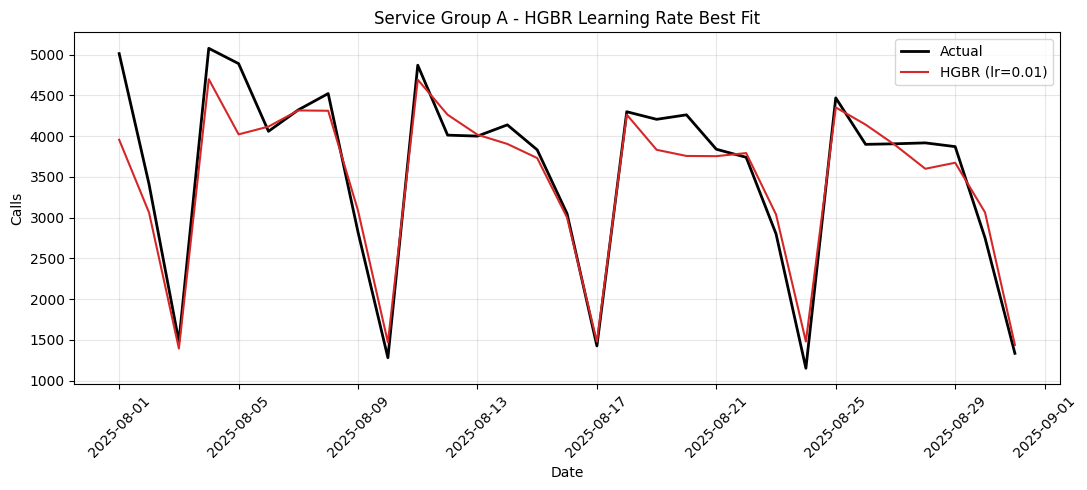

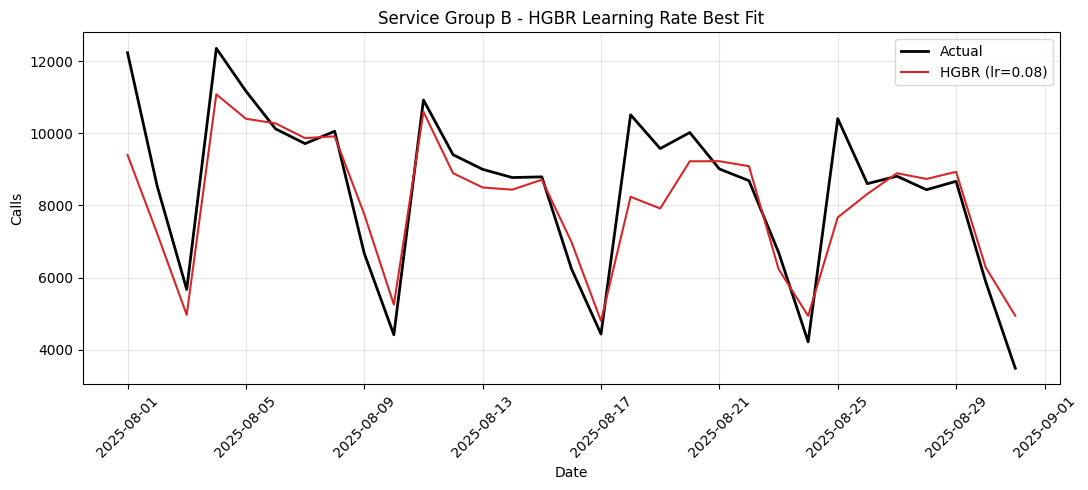

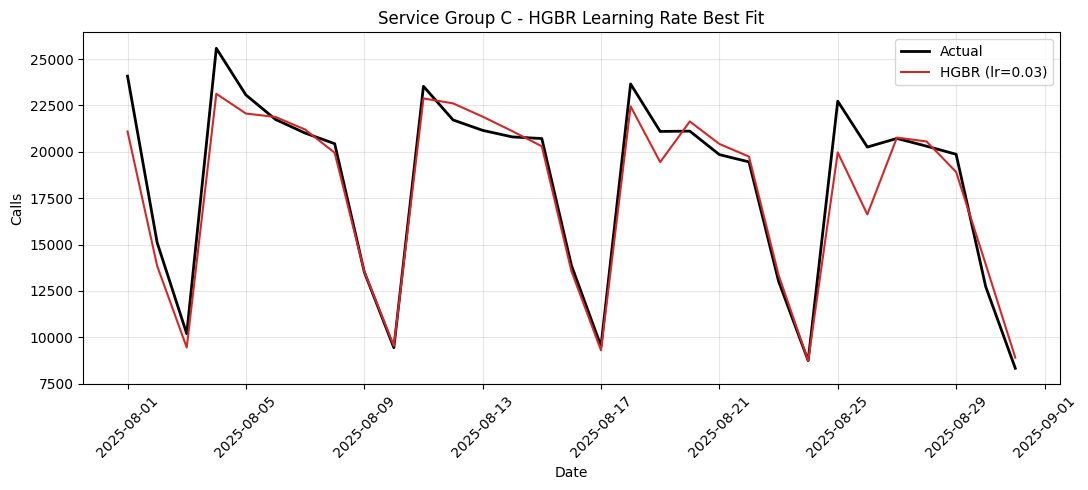

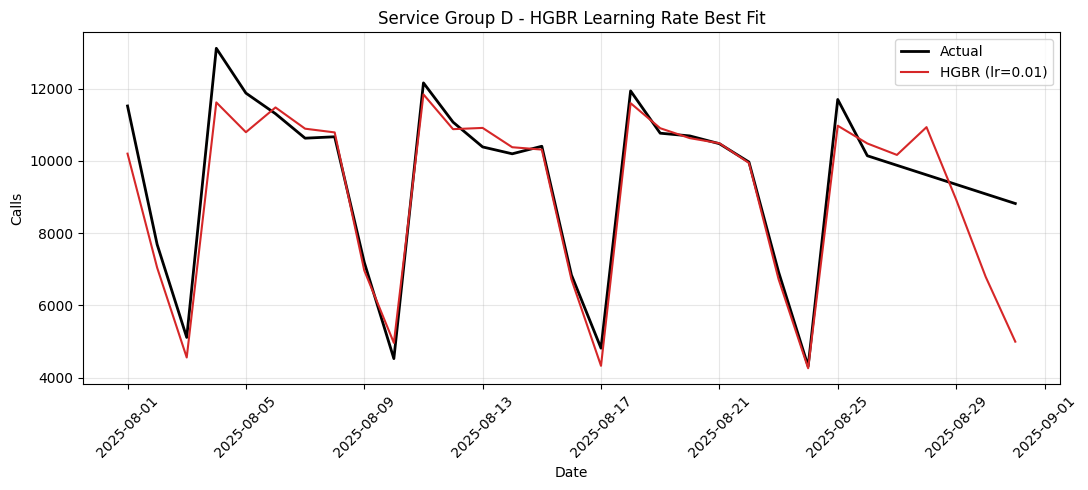

,group,lr,mse,rmse,r2
0,A,0.01,1.080617e+05,328.727401,0.916653
1,A,0.03,1.101039e+05,331.819129,0.915078
2,A,0.05,1.091011e+05,330.304620,0.915852
3,A,0.08,1.162916e+05,341.015591,0.910306
4,B,0.01,1.181744e+06,1087.080583,0.777270
5,B,0.03,1.276855e+06,1129.979966,0.759344
6,B,0.05,1.258383e+06,1121.776890,0.762825
7,B,0.08,1.142384e+06,1068.823692,0.784688
8,C,0.01,1.725433e+06,1313.557551,0.933062
9,C,0.03,1.582471e+06,1257.962998,0.938608


In [47]:
# Learning-rate sweep for HistGradientBoosting (all service groups)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor

hgbr_learning_rates = [0.01, 0.03, 0.05, 0.08]
hgbr_lr_results = []
best_preds_hgbr = {}

for g, (daily_df, interval_df) in groups.items():
    df = _prepare_daily_hgbr(daily_df)
    train_df = df[df["year_month"] < "2025-08"].copy()
    test_df = df[df["year_month"] == "2025-08"].copy()

    X_cols = [c for c in train_df.columns if c not in ["Date", "year_month", "Call Volume"]]
    X_train = train_df[X_cols].values
    y_train = np.log1p(train_df["Call Volume"].values)
    X_test = test_df[X_cols].values
    y_test = test_df["Call Volume"].values

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    best = None
    for lr in hgbr_learning_rates:
        hgbr = HistGradientBoostingRegressor(
            learning_rate=lr,
            max_depth=7,
            max_leaf_nodes=63,
            min_samples_leaf=5,
            l2_regularization=5e-3,
            loss="squared_error",
            early_stopping=True,
            validation_fraction=0.20,
            n_iter_no_change=50,
            max_iter=1200,
            random_state=42,
        )
        hgbr.fit(X_train_s, y_train)
        test_pred = np.expm1(hgbr.predict(X_test_s))
        mse = mean_squared_error(y_test, test_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, test_pred)
        hgbr_lr_results.append({"group": g, "lr": lr, "mse": mse, "rmse": rmse, "r2": r2})
        if best is None or mse < best[0]:
            best = (mse, lr, test_df.assign(HGBR_LR=test_pred))

    best_mse, best_lr, best_df = best
    best_preds_hgbr[g] = (best_lr, best_df)

    plt.figure(figsize=(11, 5))
    dates = pd.to_datetime(best_df["Date"])
    plt.plot(dates, best_df["Call Volume"], label="Actual", color="black", linewidth=2)
    plt.plot(dates, best_df["HGBR_LR"], label=f"HGBR (lr={best_lr})", color="#d62728")
    plt.title(f"Service Group {g} - HGBR Learning Rate Best Fit")
    plt.xlabel("Date")
    plt.ylabel("Calls")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.grid(alpha=0.3)
    plt.show()

pd.DataFrame(hgbr_lr_results)


### Best learning-rate comparison plots (XGB lagged vs HGBR)
Plots Actual vs the best-learning-rate models for each service group. Run after the sweep cells so `best_preds_xgb` and `best_preds_hgbr` are populated.

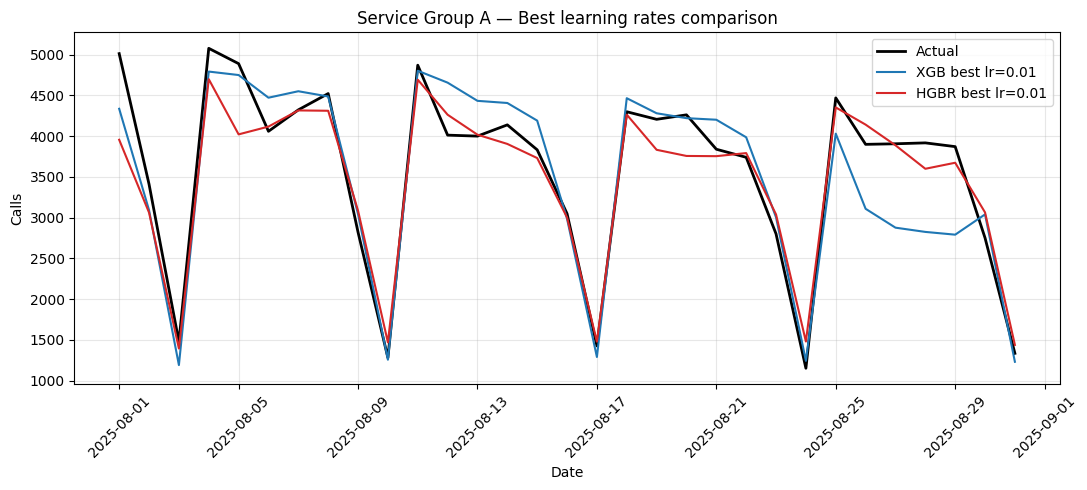

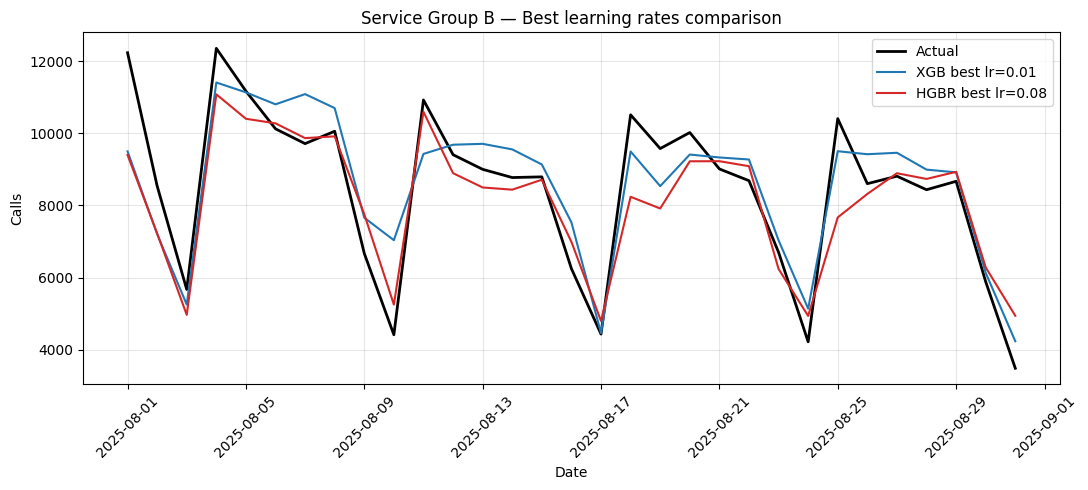

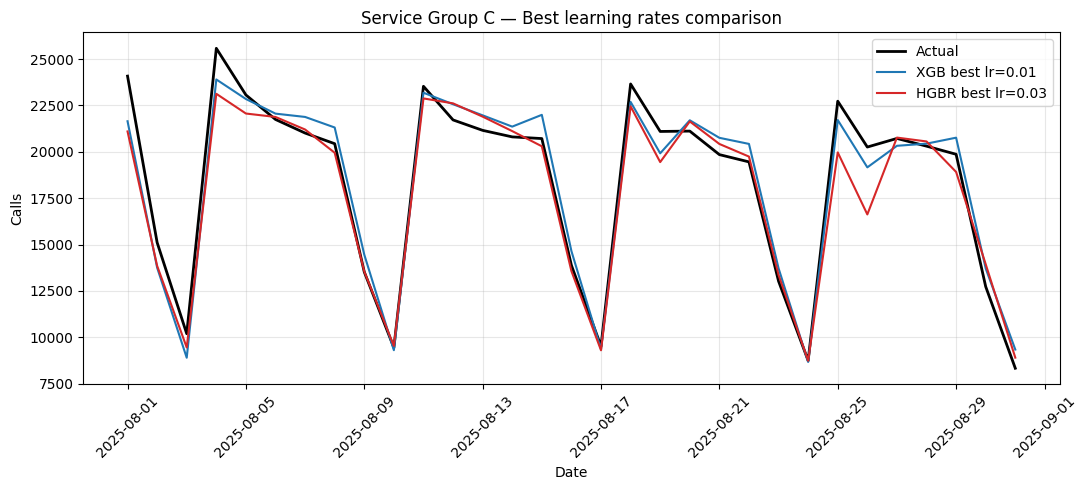

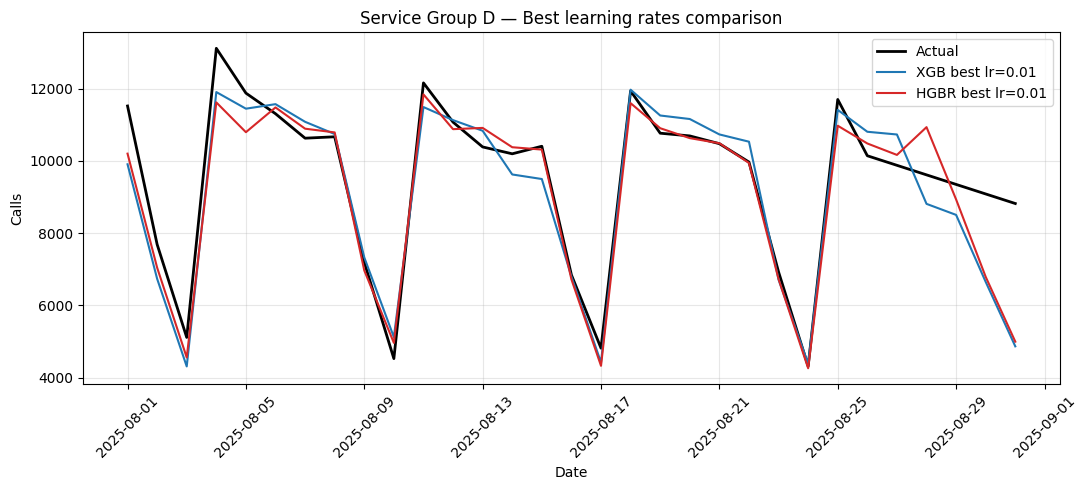

In [49]:
# Plot Actual vs best-learning-rate XGB (lagged) and HGBR for all groups
import matplotlib.pyplot as plt
import pandas as pd

if not best_preds_xgb or not best_preds_hgbr:
    raise RuntimeError("Run the learning-rate sweep cells first to populate best_preds_xgb/best_preds_hgbr.")

for g in ["A", "B", "C", "D"]:
    best_lr_xgb, best_df_xgb, pred_col_xgb = best_preds_xgb[g]
    best_lr_hgbr, best_df_hgbr = best_preds_hgbr[g]

    # align on Date
    dx = best_df_xgb[['Date', 'Call Volume', pred_col_xgb]].rename(columns={pred_col_xgb: 'XGB_best'})
    dh = best_df_hgbr[['Date', 'Call Volume', 'HGBR_LR']].rename(columns={'HGBR_LR': 'HGBR_best'})
    merged = pd.merge(pd.to_datetime(dx['Date']).to_frame(name='Date'), dx[['Call Volume','XGB_best']], left_index=True, right_index=True, how='left')
    merged['HGBR_best'] = dh['HGBR_best'].values
    merged['Actual'] = merged['Call Volume']

    plt.figure(figsize=(11,5))
    dates = pd.to_datetime(dx['Date'])
    plt.plot(dates, merged['Actual'], label='Actual', color='black', linewidth=2)
    plt.plot(dates, merged['XGB_best'], label=f'XGB best lr={best_lr_xgb}', color='#1f77b4')
    plt.plot(dates, merged['HGBR_best'], label=f'HGBR best lr={best_lr_hgbr}', color='#d62728')
    plt.title(f'Service Group {g} — Best learning rates comparison')
    plt.xlabel('Date')
    plt.ylabel('Calls')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.grid(alpha=0.3)
    plt.show()
